# Project: Operations Research

## Table of Contents

1. Context and problem statement
2. Graph modeling
   - 2.1 Graph definition
   - 2.2 Road blockages
   - 2.3 Cost matrices definition
   - 2.4 Tour dynamics
3. Problem modeling
   - 3.1 Decision variables
   - 3.2 Time definition
   - 3.3 Objective function
   - 3.4 Constraints
     - 3.4.1 Number of visits
     - 3.4.2 Visiting all nodes
4. Problem complexity
   - 4.1 Decision version
   - 4.2 Membership in NP
     - Certificate
     - Input size
     - Step 1: Domain check of variables
     - Step 2: Flow constraints check
     - Step 3: Node visit check
     - Step 4: Consistency with the graph
     - Step 5: Total cost computation
     - Step 6: Comparison with threshold
     - Overall complexity
   - 4.3 NP-hardness
     - 4.3.1 TSP instance
     - 4.3.2 Construction
     - 4.3.3 Interpretation
     - 4.3.4 Equivalence proof
   - 4.4 Conclusion
5. Modeling of initial graphs
6. Solution methods
   - 6.1 Positioning on complete graphs
   - 6.2 Experimental plan
     - Goal
     - General protocol
     - Phase 1: Hyperparameter tuning (OFAT)
     - Phase 2: Validate best parameters
     - Phase 3: Sensitivity to instance parameters
     - Phase 4: Robustness (100 runs)
     - Final indicators
   - 6.3 Continuous relaxation and lower bound
     - Principle of continuous relaxation
     - Lower bound
     - Relaxed mathematical formulation
     - Python implementation (PuLP)
   - 6.4 Choice of solution methods
     - 6.4.1 Ant Colony Optimization (ACO)
       - General principle
       - Constructing a solution
       - Pheromone update
       - Adaptations for the dynamic problem
     - 6.4.2 Genetic Algorithm (GA)
       - General principle
       - Solution representation
       - Evaluation function (fitness)
       - Initial population
       - Selection
       - Crossover
       - Mutation
       - Elitism
7. GA implementation
   - Hyperparameter tuning (OFAT)
     - Main results
     - Analysis
     - General conclusion
   - Impact of instance parameters
     - Study objective
     - Why use a genetic algorithm?
     - Parameters studied
     - Impact of number of cost matrices
     - Impact of blockage probability
     - Impact of number of nodes
   - Influence of number of dynamic matrices (K)
   - Influence of blockage probability
   - Influence of number of nodes (n)
   - Final result and gap to lower bound
8. ACO implementation
   - Hyperparameter tuning (OFAT)
     - Main results
     - Analysis
     - Limitations
     - General conclusion
   - Impact of instance parameters
     - Impact of number of cost matrices
     - Impact of blockage rate
     - Impact of number of nodes
   - Influence of number of dynamic matrices (K)
   - Influence of blockage probability
   - Influence of number of nodes (n)
   - Final result and gaps to lower bound
9. Conclusion
   - 9.1 Project summary
   - 9.2 Result analysis
     - Solution quality
     - GA vs ACO comparison
     - Impact of instance parameters


## 1. Context and problem statement

This notebook was prepared in response to an ADEME call for proposals and addresses the problem of optimizing delivery tours on an urban road network.
The goal is to minimize the total cost of a tour that visits a set of cities, starting and ending at a depot, while accounting for realistic constraints: some roads are expensive or temporarily blocked, and traffic conditions evolve dynamically over time.

This problem belongs to the family of Traveling Salesman Problems (TSP), specifically a richer variant that includes:

- variable edge costs (surcharges or blocked roads)
- dynamic network perturbations

To address this problem we first discuss how to represent it and how to model it mathematically. We then solve it using several metaheuristics, compare their performance, and tune them to find the best possible solutions.


## 2. Graph modeling

### 2.1 Graph definition

We model the road network as a weighted undirected dynamic graph:

$$G = \left(V,\, E,\, (C^1, C^2, \dots, C^K)\right)$$

where:

- $V = \{v_1, v_2, \dots, v_n\}$ is the set of vertices (cities or delivery points), with $v_0$ as the depot (start and end point);
- $E \subseteq \{\{i,j\} : i,j \in V,\, i \neq j\}$ is the set of edges representing roads between cities;
- $(C^1, C^2, \dots, C^K)$ is the family of cost matrices indexed by $k \in \{1, 2, \dots, K\}$.

Each $C^k$ is a symmetric $|V| \times |V|$ matrix whose entry $C_{ij}^{k} \in \mathbb{N} \cup \{+\infty\}$ denotes the travel cost (in minutes) of edge $\{i,j\}$ when matrix $C^k$ is active.

Let $n = |V|$ be the number of cities to visit (excluding the depot) and $K$ the number of matrices in the family (upper bound on distinct steps before the cycle repeats).

### 2.2 Road blockages

We first define the nominal matrix $C^{\text{init}}$, where $C^{\text{init}}_{ij}$ is the base travel time for edge $\{i,j\}$ in the absence of perturbations and blockages.

Some roads may be impassable (e.g., works). This is modeled by a blockage matrix $B$:

$$B_{ij} \in \{1,\, +\infty\}, \quad \forall \, \{i,j\} \in E$$

with:

- $B_{ij} = 1$ if road $\{i,j\}$ is passable,
- $B_{ij} = +\infty$ if road $\{i,j\}$ is blocked.

The blockage matrix is symmetric: $B_{ij} = B_{ji}$.

The initial cost matrix $C^{1}$ is obtained by combining the nominal matrix and the blockages:

$$C^{1}_{ij} = B_{ij} \cdot C^{\text{init}}_{ij}, \quad \forall \, \{i,j\} \in E$$

Thus, a passable edge retains its nominal cost ($C^{1}_{ij} = C^{\text{init}}_{ij}$), while a blocked edge has infinite cost ($C^{1}_{ij} = +\infty$), making it unusable in any tour that minimizes total cost. $C^{1}$ therefore represents the network's initial state (before dynamic perturbations, but with blockages applied).

Perturbations described in section 2.3 only apply to non-blocked edges ($B_{ij} = 1$).

### 2.3 Cost matrices definition

The network experiences temporary variations in traffic conditions (works, accidents, congestion, ...), modeled by a family of surcharge matrices $(S^2, S^3, \dots, S^K)$.

Each surcharge matrix $S^k$ represents the additional cost applied to edges at step $k$ of the tour. We define:

$$S_{ij}^{k} \in \{0, 1, \dots, \Delta\}, \quad \forall \, \{i,j\} \in E, \; k \in \{2, 3, \dots, K\}$$

with $\Delta = 300$ minutes as the maximum surcharge per step. Surcharge matrices are symmetric: $S^{k}_{ij} = S^{k}_{ji}$.

For $k \geq 2$, the cost matrix $C^{k}$ is obtained by adding the current surcharge to the initial matrix $C^{1}$ (no cumulative effect across steps):

$$C_{ij}^{k} = C_{ij}^{1} + S_{ij}^{k}, \quad \forall \, \{i,j\} \in E, \; k \in \{2, \dots, K\}$$

Explicitly:

- Step 1: $C^{1}_{ij}$ (initial state, with blockages, no surcharge)
- Step 2: $C^{2}_{ij} = C^{1}_{ij} + S^{2}_{ij}$
- Step 3: $C^{3}_{ij} = C^{1}_{ij} + S^{3}_{ij}$
- $\dots$
- Step $K$: $C^{K}_{ij} = C^{1}_{ij} + S^{K}_{ij}$

Each step restarts from the initial costs $C^{1}$ and only adds the current surcharge, so for any non-blocked edge and any step $k \ge 2$ we have:

$$C_{ij}^{1} \leq C_{ij}^{k} \leq C_{ij}^{1} + \Delta$$

The dynamic thus corresponds to a bounded time surcharge between 0 and 300 minutes at each step.

### 2.4 Tour dynamics

Each time the vehicle leaves a node to reach another, the index $k$ is incremented by 1, simulating the network's evolution along the tour.

The sequence of matrices is cyclic: when $k > K$, the index is wrapped back into $\{1, \dots, K\}$ via

$$k \leftarrow ((k - 1) \bmod K) + 1$$

In other words, after using $C^{K}$ the next move uses $C^{1}$ again, then $C^{2}$, and so on.

Since the graph is undirected, each cost matrix $C^{k}$ is symmetric:

$$C_{ij}^{k} = C_{ji}^{k}, \quad \forall \, \{i,j\} \in E, \; \forall \, k \in \{1, 2, \dots, K\}$$



## 3. Problem Modeling :

### 3.1 Decision Variables :

We introduce the variable :

$$X_{ij}^k \in \mathbb{N}, \quad \forall \, (i,j) \in E, avec \; i \ne j, k \in \llbracket 1,2,..., K \rrbracket$$

$X_{ij}^k$ accounts for the number of times we have traversed $(i,j)$ when the selected cost matrix is matrix $C^k$


### 3.2 Definition of Time:

$$C_{ij}^{k} \in \mathbb{N} \cup \{+\infty\}, \quad \forall \{i,j\} \in E, \; k \in [\![1, \dots, K]\!]$$

$C_{ij}^{k}$ represents the cost (in minutes) to take the route between $i$ and $j$ when the cost matrix is in its state $k$.

- $k$: index of the selected cost matrix
- $K$: maximum number of matrices
  

### 3.3 Objective Function :

We seek to minimize the total duration of the tour:

$$\min \sum_{k} \sum_{i,j} C_{ij}^{k} \, X_{ij}^{k}$$

### 3.4 Constraints :

#### 3.4.1 Number of Passages :

$$\forall \, i, \quad \sum_{j,k} X_{ij}^k = \sum_{j,k} X_{ji}^k$$

#### 3.4.2 Visiting all vertices :

$$\sum_{j,k} \left(X_{ij}^k + X_{ji}^k\right) \geq 2 \iff \sum_{j,k} X_{ij}^k \geq 1$$

## 4. Problem Complexity

### 4.1 Decision Version

We consider a dynamic undirected graph:

INSTANCE :
- a graph $G = (V, E, (C^1, \dots, C^K))$
- a depot $v_0 \in V$
- an integer $L \in \mathbb{N}$

QUESTION:

Does there exist a solution $(X_{ij}^k)$ satisfying the constraints such that :

$$\sum_{k} \sum_{i,j} C_{ij}^{k} X_{ij}^{k} \le L \, ?$$

### 4.2 Membership in NP

We show that the problem belongs to the NP class by proving that a candidate solution can be verified in polynomial time.

#### CCertificate

A certificate is given by an assignment of variables :

$$(X_{ij}^k)_{(i,j)\in E, \; with \; i \ne j; \; k \in \{1,\dots,K\}}$$

with $X_{ij}^k \in \mathbb{N}$.

#### Input Size

- Number of vertices: $n = |V|$
- Number of edges: $|E| \leq O(n^2)$
- Number of matrices: $K$

Total number of variables :

$$O(K \cdot |E|) = O(K n^2)$$

#### Step 1: Variable Domain Verification

We verify that:

$$X_{ij}^k \in \mathbb{N}$$

for all variables.

- Number of checks: $O(K n^2)$
- Cost: $O(K n^2)$

#### Step 2: Flow Constraints Verification

We verify :

$$\forall i \in V, \quad \sum_{j,k} X_{ij}^k = \sum_{j,k} X_{ji}^k$$

  ##### Procedure

For each vertex $i$ :

- Calculation of the outgoing sum : $\sum_{j,k} X_{ij}^k$
- Calculation of the incoming sum : $\sum_{j,k} X_{ji}^k$
- Compare the two values

##### Complexity

- For a vertex : $O(Kn)$  
- For all vertices :  

$$O(n \times K n) = O(K n^2)$$

#### Step 3 :  Vertex Visitation Verification

We verify :

$$\forall i \in V, \quad \sum_{j,k} X_{ij}^k \ge 1$$

##### Procedure

For each vertex $i$ :

- Calculation of $\sum_{j,k} X_{ij}^k$
- VVerification that it is $\ge 1$

##### Complexity

- For a vertex : $O(Kn)$  
- Total :

$$O(K n^2)$$

#### Step 4 : Graph Consistency Verification

We verify that :

- If $(i,j) \notin E$, then $X_{ij}^k = 0$

##### Complexity

- For a vertex : $O(K n^2)$

#### Step 5 : Total Cost Calculation

We calculate :

$$\sum_{k=1}^{K} \sum_{(i,j)\in E} C_{ij}^{k} X_{ij}^{k}$$

##### Procedure

- For each triplet $(i,j,k)$ :
  - Multiplication $C_{ij}^k \times X_{ij}^k$
  - Addition

##### Complexity

$$O(K n^2)$$

#### Step 6 : Comparison with the Threshold

We verify :

$$\sum_{k,i,j} C_{ij}^k X_{ij}^k \le L$$

- Operation in constant time after the calculation

#### Total Complexity

Each step is in :

$$O(K n^2)$$

Therefore, the complete verification is in :

$$O(K n^2)$$

Since K is an arbitrary integer, the verification is in:
$$O(n^2)$$

#### Conclusion

The verification of a certificate is achievable in polynomial time relative to the input size.

$$\boxed{\text{The problem belongs to NP}}$$



We reduce from the classical Traveling Salesman Problem (TSP).

#### 4.3.1 TSP instance

- Complete graph $G=(V,E)$
- Cost $d(i,j) \in \mathbb{N}$
- Threshold $L$

#### 4.3.2 Construction

Build an instance of our problem as follows:

- Same vertex set $V$ and edge set $E$
- Choose an arbitrary depot $v_0$

Parameters:

- $K = 1$
- $C^1_{ij} = d(i,j)$
- No blocked edges

#### 4.3.3 Interpretation

The problem becomes:

$$
\min \sum_{i,j} d(i,j) X_{ij}
$$

subject to:

- Flow constraints
- Each vertex visited at least once


#### 4.3.4 Proof of equivalence

##### (⇒) Forward direction

Assume there exists a TSP solution, i.e., a Hamiltonian cycle:

$$C = (v_0, v_1, \dots, v_n, v_0)$$

such that:

$$\sum d(v_i, v_{i+1}) \le L$$

Construct a feasible solution $(X_{ij}^1)$ by setting:

$$
X_{ij}^1 =
\begin{cases}
1 & \text{if edge } \{i,j\} \text{ is in cycle } C \\
0 & \text{otherwise}
\end{cases}
$$

Verification:

- Flow constraints: in a Hamiltonian cycle, each vertex has exactly one incoming and one outgoing edge, so

$$\sum_j X_{ij}^1 = \sum_j X_{ji}^1$$

- Visit constraint: each vertex is visited once, hence

$$\sum_j X_{ij}^1 = 1 \ge 1$$

- Cost: since $C^1_{ij} = d(i,j)$,

$$\sum_{i,j} C_{ij}^1 X_{ij}^1 = \sum d(v_i, v_{i+1}) \le L$$

Therefore $(X_{ij}^1)$ is feasible.

##### (⇐) Reverse direction

Assume there exists a feasible solution $(X_{ij}^1)$ with

$$\sum_{i,j} C_{ij}^1 X_{ij}^1 \le L$$

**Step 1: Structure**

Flow constraints imply the graph defined by $(X_{ij}^1)$ is balanced (in-degree = out-degree) and composed of cycles (possibly multiple).

**Step 2: Simplification**

Since costs are strictly positive:

- Any repeated edges or extra cycles increase the total cost.
- Redundant cycles can be removed.

By removing redundant cycles we obtain a single cycle visiting all vertices.

**Step 3: Conclusion**

This cycle is a Hamiltonian cycle with cost ≤ $L$, so it provides a TSP solution.


### 4.4 Conclusion

We have:

$$\text{TSP} \leq_p \text{Our problem}$$

Therefore the decision problem is NP-hard.

Because it also belongs to NP:

$$\boxed{\text{NP-complete}}$$

Consequently, the optimization version of the problem is at least NP-hard.

### 4.5 Conclusion for the optimization problem

Since the associated decision problem is NP-complete, the corresponding optimization problem is NP-hard (an efficient solver for the optimization would provide a method to solve the decision problem).

## 5. Modeling of initial graphs

In [13]:
# Import all the necessary modules for the project
from pulp import *                         # Linear programming and optimization solver
import numpy as np                         # Numerical operations and array handling
import matplotlib.pyplot as plt            # Data visualization and plotting
import networkx as nx                      # Graph and network modeling (nodes/edges)
import pandas as pd                        # Data manipulation and tabular data analysis
from IPython.display import display, HTML  # Rich display formatting for Jupyter Notebooks
import time                                # Execution timing and performance tracking
from tqdm import tqdm                      # Progress bar visualization for long loops

In [14]:
def check_connexe(C, INF):
    """
    Verifies graph connectivity using a Depth-First Search (DFS) starting from node 0.
    Ignores blocked edges (weights >= INF).
    """
    n = C.shape[0]
    visited = [False] * n

    def dfs(v):
        visited[v] = True
        for u in range(n):
            if C[v, u] < INF and not visited[u]:
                dfs(u)

    dfs(0)
    return all(visited)
    
def gen_nominal_matrix(n, rng, INF, cout_min, cout_max):
    """
    Generates the initial cost matrix (C_init) for a complete undirected graph with n vertices.

    Properties:
    - Symmetric (undirected graph)
    - Zero-weight diagonal (no self-loops)
    - Edge costs are uniformly distributed integers within [cout_min, cout_max]
    """
    C_init = rng.integers(cout_min, cout_max + 1, size=(n, n))

    # Isolate the upper triangular part to enforce symmetry
    C_init = np.triu(C_init, k=1)
    C_init = C_init + C_init.T
    np.fill_diagonal(C_init, INF)
    
    return C_init 

def gen_block_matrix(n, rng, INF, p_blocage):
    """
    Generates the blockage matrix B:
        B_ij = 1     if the edge {i,j} is passable
        B_ij = +inf  if the edge {i,j} is blocked

    Properties:
    - Symmetric
    - Diagonal set to 1 (irrelevant for routing, never used)
    - Each edge is independently blocked with probability p_blocage
    """
    tirage = rng.random((n, n))
    blocage = np.triu(tirage < p_blocage, k=1)
    blocage = blocage | blocage.T

    B = np.ones((n, n), dtype=float)
    B[blocage] = INF
    
    return B

def gen_C1_matrix(C_init, B, INF):
    """
    Computes the element-wise product: C^1_ij = B_ij * C_init_ij.
        - Passable edge: C^1_ij = C_init_ij
        - Blocked edge: C^1_ij = +inf

    C^1 represents the initial network state (k=1) with blockages applied, 
    prior to any dynamic perturbations.
    """
    return np.where(B == 1, C_init, INF).astype(float)

def gen_surcost_matrices(n, K, B, rng, delta):
    """
    Generates the family of additional cost matrices (S^k) for k = 2..K.

    Properties:
    - Zero additional cost on the diagonal
    - Zero additional cost on blocked edges (perturbations only apply to passable edges)

    Returns a list of K-1 matrices corresponding to S^2, S^3, ..., S^K.
    """
    praticable = (B == 1) 

    matrices = []
    for _ in range(K - 1): 
        Ck = rng.integers(0, delta + 1, size=(n, n))
        
        # Enforce symmetry and zero-diagonal
        Ck = np.triu(Ck, k=1)
        Ck = Ck + Ck.T
        
        # Restrict perturbations to valid edges
        Ck = np.where(praticable, Ck, 0).astype(float)
        matrices.append(Ck)
        
    return matrices

def effective_cost_k(C1, Sk):
    """
    Computes the effective cost matrix at step k >= 2: C^k = C^1 + S^k.
    Blocked edges implicitly remain at +inf.
    """
    return C1 + Sk

def build_all_Ck(C1, surcouts):
    """
    Constructs and returns the complete list of cost matrices C^k for k = 1..K.
    """
    C_list = [C1] + [effective_cost_k(C1, Sk) for Sk in surcouts]
    return C_list  

def get_Ck(C_list, K, k):
    """
    Retrieves the matrix C^k, utilizing modulo arithmetic to handle cyclic time steps.
    """
    idx = (k - 1) % K 
    return C_list[idx]

def print_mat(M, INF):
    """
    Utility function to format and print matrices, displaying blocked edges as 'INF'.
    """
    fmt = lambda x: '  INF' if x >= INF else f'{int(x):5d}'
    for row in M:
        print(' '.join(fmt(x) for x in row))

Here we create the matrices used in our modeling. We first construct a matrix for a complete graph and then remove some edges according to a blockage matrix. We then generate additional surcharge matrices which are used to build the dynamic cost matrices.

In [15]:
# Network and simulation hyperparameters
n = 20                # Total number of vertices (including the depot)
K = 5                 # Total number of dynamic cost matrices in the sequence (C^1 to C^K)
DELTA = 300           # Maximum stochastic penalty (perturbation) applied to edges
MAX_STEPS = n * 5     # Upper bound on routing steps to prevent infinite loops in heavily blocked topologies
MAX_PRINT_STEPS = K   # Number of temporal matrices to output for verification

# Initialize Pseudo-Random Number Generator (PRNG) for strict reproducibility
rng = np.random.default_rng(42) 

# Numerical surrogate for +infinity to ensure stability in cost-based minimizations
INF = 1e12 

# ==========================================
# Network Topology & State Initialization
# ==========================================

# 1. Base network topology (Complete undirected graph with nominal weights)
C_init = gen_nominal_matrix(n, rng, INF, cout_min=1, cout_max=60) 

# 2. Blockage matrix (Models structural network failures/disruptions)
B = gen_block_matrix(n, rng, INF, p_blocage=0.25)

# 3. Initial state matrix C^1 (Applies structural blockages to the nominal base)
C1 = gen_C1_matrix(C_init, B, INF) 

# 4. Generate dynamic perturbation matrices (S^2 ... S^K) for time-dependent routing
surcouts = gen_surcost_matrices(n, K, B, rng, DELTA)

# Construct the complete chronological sequence of cost matrices for the simulation
C_list = build_all_Ck(C1, surcouts)

# ==========================================
# State Verification & Output
# ==========================================

print("C^init (Nominal base matrix)")
print_mat(C_init, INF)

print("\nB (Blockage matrix / Failure mask)")
print_mat(B, INF)

# Display the dynamic evolution of the cost matrices over the discrete time steps
for k in range(1, MAX_PRINT_STEPS + 1):
    Ck = get_Ck(C_list, K, k)
    print(f"\nC^{k} (Effective cost matrix at time step {k})")
    print_mat(Ck, INF)

C^init (Nominal base matrix)
  INF    47    40    27    26    52     6    42    13     6    32    59    45    46    44    48    31     8    51    28
   47   INF    11    56    47    39    25    50    33    27    28    14     6    34    54     4    52    50    17    38
   40    11   INF    22     5    59    27    54    41    47    46    12    22    29    30     3    33    10    45    41
   27    56    22   INF    25    20    55    23     5    29    48    12    28     8    42    29    20    14    34    41
   26    47     5    25   INF    43     6    19    47    50    27    49    51    24    54    18    15    41    39     9
   52    39    59    20    43   INF    47    40    29    43    17    47    34    28    31    35     3     9    15     7
    6    25    27    55     6    47   INF    46    35    39    34    34     6    34    48    19    37     2    21    27
   42    50    54    23    19    40    46   INF    50     4    52    17    56    18    27    40     8    34    31    48
   13    33

In [16]:
def visualize_route(C_matrix, INF, n, route=None, title="Network Graph"):
    """
    Renders a structural visualization of the network topology and optional routing paths.
    
    Parameters:
    - C_matrix: The cost matrix defining the network's current state.
    - INF: The numerical threshold representing blocked/impassable edges.
    - n: Total number of nodes (including the depot).
    - route: Optional list of nodes representing the calculated path.
    - title: String title for the generated plot.
    """
    
    # 1. Route Sanitization
    # Enforce strict structural integrity for the path: Depot (0) -> Nodes -> Depot (0)
    if route is not None:
        clean_route = [node for node in route if node != 0]
        route = [0] + clean_route + [0]         

    # 2. Graph Construction
    G = nx.DiGraph()
    G.add_nodes_from(range(n))

    # Populate the graph exclusively with actionable (unblocked) edges
    for i in range(n):
        for j in range(n):
            if i != j and C_matrix[i][j] < INF:
                G.add_edge(i, j, weight=C_matrix[i][j])

    # 3. Spatial Layout & Rendering
    plt.figure(figsize=(10, 8))
    
    # Apply a circular layout for consistent spatial mapping across multiple visual states
    pos = nx.circular_layout(G) 
    
    # Render standard operational nodes (cities)
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=600, edgecolors='black')
    
    # Emphasize the primary depot (Node 0) in the visual hierarchy
    nx.draw_networkx_nodes(G, pos, nodelist=[0], node_color='lightgreen', node_size=800, edgecolors='black')
    
    # Apply standard typography for node identifiers
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

    if route is None:
        # Baseline Mode: Display the entire grid of actionable network edges
        nx.draw_networkx_edges(G, pos, edge_color='gray', alpha=0.5, arrows=False)
    else:
        # Overlay Mode: Dim the underlying grid to highlight the calculated traversal path
        nx.draw_networkx_edges(G, pos, edge_color='whitesmoke', alpha=0.3, arrows=False)
        
        # Extract edge pairs chronologically from the sanitized route
        route_edges = [(route[i], route[i+1]) for i in range(len(route)-1)]
        
        # Render the optimized route with distinct directional indicators
        nx.draw_networkx_edges(
            G, pos, 
            edgelist=route_edges, 
            edge_color='red', 
            width=2.5, 
            arrows=True, 
            arrowstyle='-|>', 
            arrowsize=20
        )

    plt.title(title, fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.show()

We display the graph corresponding to the first cost matrix.

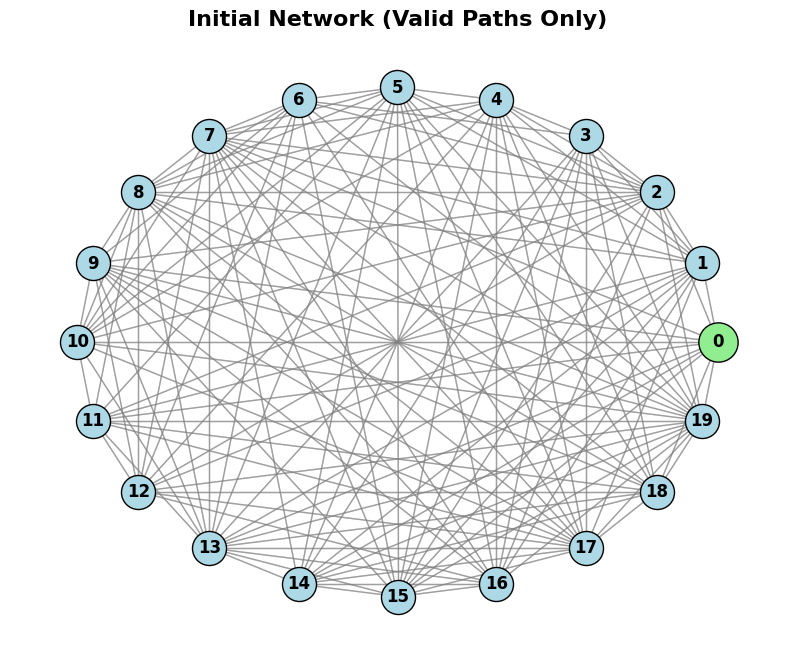

In [17]:
# Shows all possible paths, but blocked paths (INF_INT) will not be drawn
visualize_route(C_list[0], INF, n, route=None, title="Initial Network (Valid Paths Only)")

# 6. Solution method

## 6.1 Positioning on complete graphs

Our problem is defined on a graph that may be incomplete: some edges are blocked ($C_{ij}^k = +\infty$), so the underlying graph is generally not complete.

However, some algorithms are designed to operate on a weighted complete graph where every pair of vertices is connected by a finite-cost edge. Positioning on a complete graph is justified by:

- Modeling generality: blocked edges are represented by cost $+\infty$, which makes them inaccessible when constructing solutions. The graph remains technically complete, but blocked edges will never be used because they cannot reduce the total cost.
- Algorithmic robustness: working on a complete graph simplifies algorithmic structure without loss of generality, since blockages are fully encoded in the cost matrices.

Thus, treating the problem on a complete graph is a modeling abstraction, not a simplification of the real problem.

### General protocol
- Select the metaheuristics to test
- Run the selected metaheuristics with default/initial parameters
- Test the impact of metaheuristic parameters
- Test the impact of instance parameters
- Report final results after parameter tuning

### Phase 1: Hyperparameter tuning (OFAT)
One-Factor-At-A-Time method with cost/time trade-off:

- **GA**:
  - Parameters tested: `pop_size`, `mutation_rate`, `elite_size`
  - Tuning seeds: `SEEDS_TUNE = [42, 99, 137]`
  - Tuning generations: `GEN_SEARCH = 200`

- **ACO**:
  - Parameters tested: `num_ants`, `alpha`, `beta`, `evaporation_rate`
  - Tuning seeds: `SEEDS_TUNE = [42, 99, 137]`
  - Tuning iterations: `ITER_SEARCH = 100`

The best configuration is chosen using a compromise score (normalized cost + runtime).

#### Hyperparameter selection criterion

To identify a good trade-off between solution quality and runtime, we define an aggregated score using min-max normalization of both criteria.

For each tested configuration record:
- C: mean solution cost,
- T: mean convergence time.

Normalize both metrics using min-max:

$$
C_{\text{norm}} = \frac{C - C_{\min}}{C_{\max} - C_{\min}}, \quad
T_{\text{norm}} = \frac{T - T_{\min}}{T_{\max} - T_{\min}}
$$

If there is no variance (i.e., $C_{\max} = C_{\min}$ or $T_{\max} = T_{\min}$), the corresponding normalized term is set to 0 to avoid numerical bias.

The global score is then defined as a linear combination:

$$
\text{score} = \lambda \cdot C_{\text{norm}} + (1 - \lambda) \cdot T_{\text{norm}}
$$

where $\lambda \in [0,1]$ controls the relative weight between solution quality and runtime.

In this study we choose $\lambda = 0.5$, giving equal importance to performance and speed. The configuration minimizing this score is selected.

### Phase 2: Validation of best parameters
Evaluate chosen parameters on seeds not used in tuning:

- SEEDS_FINAL = `[42, 99, 137, 201, 314]`
- GA : `GEN_FINAL = 500`
- ACO : `ITER_FINAL = 300`

Reported statistics: mean, minimum, standard deviation of costs + convergence curves.

### Phase 3: Sensitivity to instance parameters
Separate study of the impact of:
1. $K$: number of dynamic matrices,
2. $p_{block}$: edge blockage probability,
3. $n$: number of nodes.

Protocol:
- `NB_RUNS = 10` per configuration,
- Regenerate the instance at each run,
- Filter out non-connected graphs,
- Track average cost and convergence time (with dispersion).

### Phase 4: Robustness (100 runs)
For each metaheuristic:
- 100 runs with best parameters,
- Extract the global best tour,
- Distribution of obtained costs.

Then compute the relative gap to the lower bound:
$$
\text{gap}(\%) = \frac{\text{cost} - \text{lower bound}}{\text{lower bound}} \times 100
$$
and visualize it as a histogram with mean and median markers.

### Final indicators
- Quality: mean / min / std of cost
- Speed: mean convergence time
- Robustness: inter-run variance
- Theoretical reference: gap to the relaxed lower bound

In this relaxed model, movements can be fractional. For example:

$$
X_{AB}=0.25
$$

means that mathematically only 25% of the movement from $A$ to $B$ is performed.

This has no physical meaning but it allows us to:

- Transform the combinatorial problem into a continuous one,
- Obtain a solution that is much easier to compute.

### Lower bound

The relaxation permits more freedom than the original discrete problem. Since we minimize the objective, the relaxation's optimal value can never be higher than the true optimal cost:

$$
\text{Relaxation cost} \le \text{True optimal cost}
$$

Therefore the relaxation value is a valid lower bound.

It represents the theoretical minimal cost achievable when discrete constraints are removed. The relaxation is not intended to produce a feasible tour, but to provide a mathematical reference.

### Relaxed mathematical formulation

#### Variables

$$
x_{ij}^k \ge 0
$$

Real variables representing fractional flows.

#### Objective function

Minimize the total travel cost:

$$
\min \sum_{k} \sum_{i} \sum_{j} C_{ij}^k \, x_{ij}^k
$$

where $C_{ij}^k$ is the cost to go from city $i$ to city $j$ at time $k$.

#### Constraints

1. Flow conservation: each city preserves the same incoming and outgoing flow:

$$
\sum_{j,k} x_{ij}^k = \sum_{j,k} x_{ji}^k
$$

2. Minimum visit frequency: each city must be reached at least once:

$$
\sum_{j,k} x_{ij}^k \ge 1
$$


### Python implementation (PuLP)

In [18]:
def relaxation_continue_time_expanded(C_list, n, K):    
    """
    Computes the continuous relaxation lower bound for the dynamic routing problem 
    using a time-expanded network formulation.
    """
    # Total discrete time steps required to complete a full tour (n nodes = n edges)
    T = n                   

    # Initialize the linear programming model for continuous relaxation
    prob = LpProblem("Time_Expanded_Continuous_Relaxation", LpMinimize)

    # Decision variables x[i, j, t] ∈ [0, 1] 
    # Represents the fraction of the route traversing from node i to node j at time step t
    x = {}
    
    for t in range(1, T + 1):
        # Determine the active dynamic cost matrix index for the current time step
        k_idx = (t - 1) % K
        
        for i in range(n):
            for j in range(n):
                # Filter out self-loops and structurally blocked edges
                if i != j and C_list[k_idx][i][j] < INF:
                    
                    # Topological restriction 1: Prevent premature returns to the depot
                    if j == 0 and t < T:
                        continue
                    
                    # Topological restriction 2: Prevent multiple departures from the depot
                    if i == 0 and t > 1:
                        continue
                        
                    # Initialize the continuous variable
                    x[i, j, t] = LpVariable(f"x_{i}_{j}_t{t}", lowBound=0)

    # Objective Function: Minimize the exact dynamic cost over the time-expanded network
    prob += lpSum(C_list[(t - 1) % K][i][j] * x[i, j, t] for (i, j, t) in x)

    # Constraint 1: Source initialization (100% of the flow must leave the depot at t=1)
    prob += lpSum(x[0, j, 1] for j in range(1, n) if (0, j, 1) in x) == 1, "Depot_Departure"

    # Constraint 2: Strict flow conservation (Temporal continuity)
    # The inflow to node j at time t must exactly equal the outflow from node j at time t+1
    for t in range(1, T):
        for j in range(1, n): 
            inflow = lpSum(x[i, j, t] for i in range(n) if (i, j, t) in x)
            outflow = lpSum(x[j, l, t + 1] for l in range(n) if (j, l, t + 1) in x)
            prob += (inflow == outflow, f"Flow_Conservation_Node_{j}_Step_{t}")

    # Constraint 3: Node covering (Each city must be serviced at least once)
    for j in range(1, n):
        prob += lpSum(x[i, j, t] for (i, dest, t) in x if dest == j) >= 1, f"Visit_Requirement_{j}"

    # Constraint 4: Sink termination (100% of the flow must return to the depot at step T)
    prob += lpSum(x[i, 0, T] for i in range(1, n) if (i, 0, T) in x) == 1, "Depot_Return"

    # Execute the CBC solver silently (suppress internal logging for clean output)
    prob.solve(PULP_CBC_CMD(msg=False))

    # Extract and return the objective value if an optimal continuous solution is found
    if LpStatus[prob.status] == "Optimal":
        return value(prob.objective)

    return None

# ==========================================
# Execution & Result Extraction
# ==========================================

actual_lower_bound = relaxation_continue_time_expanded(C_list, n, K)
print("Lower Bound (Continuous Time-Expanded Relaxation):", actual_lower_bound)

Lower Bound (Continuous Time-Expanded Relaxation): 831.1818172909999


### Pheromone update

At the end of each iteration pheromones are updated in two steps:

1. Evaporation: all pheromones are reduced by a factor $(1 - \rho)$ to avoid premature convergence:

$$\tau_{ij} \leftarrow (1 - \rho) \times \tau_{ij}$$

2. Deposit: each ant that found a feasible solution deposits an amount of pheromone inversely proportional to the tour cost:

$$\tau_{ij} \leftarrow \tau_{ij} + \frac{Q}{\text{tour cost}}$$

The deposit is symmetric (on $\tau_{ij}$ and $\tau_{ji}$) since the graph is undirected.

### Adaptations for the dynamic problem

Unlike the classical TSP, our problem has costs that change at each move. The heuristic $\eta_{ij} = 1 / C_{ij}^k$ is therefore re-evaluated at each step $k$ using the active matrix $C^k$, allowing ants to account for network dynamics during tour construction.

[Go to ACO implementation](#7-implementation-du-aco)

## 6.4.1 Ant Colony Optimization (ACO)
### General Principle
 
The Ant Colony Optimization (ACO) algorithm is inspired by the behavior of real ants which, while foraging for food, deposit pheromones on the paths they travel. Subsequent ants are attracted to paths with higher pheromone concentrations, which reinforces good solutions and collectively allows an optimal path to emerge.
 
### Solution Construction

Each ant constructs a tour starting from the depot $v_0$ and choosing the next city at each step $k$ according to a probability proportional to two factors :
 
$$P(j \mid i, k) = \frac{\tau_{ij}^{\alpha} \times \eta_{ij}^{\beta}}{\sum_{l \in \mathcal{N}} \tau_{il}^{\alpha} \times \eta_{il}^{\beta}}$$
 
where :
- $\tau_{ij}$ : pheromone intensity on the edge $\{i,j\}$
- $\eta_{ij} = \frac{1}{C_{ij}^k}$ : visibility (inverse of the cost, at step $k$)
- $\alpha$ : weight assigned to pheromones (exploitation of past good solutions)
- $\beta$ : weight assigned to visibility (local greedy heuristic)
- $\mathcal{N}$ : set of cities accessible from $i$ at step $k$ (unblocked edges)
The cities not yet visited are **prioritized** during the choice. If no unvisited city is accessible, the ant can backtrack.
 
### Pheromone Update

At the end of each iteration, the pheromones are updated in two steps :
 
1. Evaporation: All pheromones are reduced by a factor $(1 - \rho)$ to avoid premature convergence :
$$\tau_{ij} \leftarrow (1 - \rho) \times \tau_{ij}$$
 
2. Deposit: Each ant that has found a feasible solution deposits a quantity of pheromone inversely proportional to the cost of its tour :
$$\tau_{ij} \leftarrow \tau_{ij} + \frac{Q}{\text{tour cost}}$$
 
The deposit is symmetric (on both $\tau_{ij}$ and $\tau_{ji}$) since the graph is undirected.
 
### Adaptations to the Dynamic Problem

Unlike the classic TSP, our problem features costs that vary with each movement. The heuristic $\eta_{ij} = \frac {1}{C_{ij}^k}$ is therefore re-evaluated at each step $k$, using the active matrix $C^k$, which allows the ants to account for the network dynamics during the construction of the tour.

[Go to ACO](#7-implementation-du-aco)

## 6.4.2 Genetic Algorithm (GA)

### General principle

A genetic algorithm models the evolution of a population of candidate solutions across generations. At each generation, the best solutions are selected, crossed to produce offspring, and randomly mutated. This iterative process mimics Darwinian selection and tends to converge the population toward high-quality solutions.

### Solution representation

An individual is represented by an ordered list of cities to visit, excluding the depot $v_0$ (the depot is implicitly the start and end). For example, for 4 cities:

$$\text{Route} = [3, 1, 4, 2] \implies \text{Tour} : v_0 \to 3 \to 1 \to 4 \to 2 \to v_0$$

Route length is bounded by $\text{max\_steps} - 1$ (the last step reserved for returning to the depot), which allows variable-length routes and permits revisits.

### Fitness function

The tour cost is computed taking into account dynamic cost matrices. At each move the active matrix is $C^k$ with $k$ incremented cyclically.

### Initial population

The initial population is generated by a nearest-neighbor heuristic on the graph defined by $C^1$ (initial state with blockages). For diversity, the candidate city order is first shuffled randomly; then the tour is built step by step choosing at each step the closest unvisited city among accessible neighbors. If the graph is too incomplete for this construction, random permutations are used as a fallback. This strategy ensures admissible, reasonably good initial solutions.

### Selection

Selection is performed by tournament: at each selection, $k$ individuals are sampled uniformly at random and the best (lowest cost) is chosen as a parent. This favors strong solutions while maintaining diversity.

### Crossover

The crossover operator combines two parents $p_1$ and $p_2$ by concatenating a prefix of $p_1$ with a suffix of $p_2$, with cut points chosen at random. Cities missing from the child are reinserted at the first feasible position (respecting accessibility constraints) to ensure all cities are visited at least once. The child's length is truncated if necessary to not exceed `max_steps - 1`.

### Mutation

Three mutation types are applied uniformly at random, each with probability $1/3$:

| Type | Description | Role |
|---|---|---|
source
### General principle

The Ant Colony Optimization algorithm is inspired by real ants that deposit pheromones while foraging. Subsequent ants are attracted to stronger pheromone trails, which reinforces good solutions and leads the colony to collectively discover high-quality paths.

### Solution construction

Each ant builds a tour starting from the depot $v_0$. At each step $k$ the next city is chosen with probability proportional to two factors:

$$P(j \\mid i, k) = \\frac{\tau_{ij}^{\alpha} \\times \\eta_{ij}^{\beta}}{\sum_{l \\in \\mathcal{N}} \\tau_{il}^{\alpha} \\times \\eta_{il}^{\beta}}$$

where:
- $\tau_{ij}$ is the pheromone intensity on edge $\{i,j\}$
- $\eta_{ij} = 1 / C_{ij}^k$ is the visibility (inverse of cost at step $k$)
- $\alpha$ weights pheromone influence (exploitation of past good solutions)
- $\beta$ weights visibility (local greedy heuristic)
- $\mathcal{N}$ is the set of accessible cities from $i$ at step $k$ (unblocked edges)

Unvisited cities are prioritized in the selection; if none are accessible, the ant may revisit nodes.

### Pheromone update

At the end of each iteration pheromones are updated in two phases:

1. Evaporation: all pheromones are reduced by factor $(1 - \\rho)$ to avoid premature convergence:
$$\tau_{ij} \\leftarrow (1 - \\rho) \\times \\tau_{ij}$$

2. Deposit: each ant that found a feasible solution deposits pheromone inversely proportional to its tour cost:
$$\tau_{ij} \\leftarrow \\tau_{ij} + \\frac{Q}{\text{tour cost}}$$

Deposits are symmetric on $\tau_{ij}$ and $\tau_{ji}$ since the graph is undirected.

### Adaptations for the dynamic problem

Unlike classical TSP, costs change at each move. The heuristic $\eta_{ij} = 1 / C_{ij}^k$ is therefore reevaluated at every step $k$ using the active matrix $C^k$, allowing ants to account for network dynamics during tour construction.

[Go to ACO implementation](#7-implementation-du-aco)

# 7. GA implementation

In [19]:
def tsp_fitness(route, C_list, K):
    """
    Evaluates the chronological fitness of a proposed route.
    Computes the total traversal cost by synchronizing the route sequence 
    with the time-dependent dynamic cost matrices (C^k).
    """
    cost = 0
    k = 1
    current = 0
    
    for city in route:
        Ck = get_Ck(C_list, K, k)
        cost += Ck[current][city]
        current = city
        k += 1
        
    # Add the final return trip to the depot (Node 0)
    Ck = get_Ck(C_list, K, k)
    cost += Ck[current][0]
    
    return cost


def nearest_neighbor_route(C_list, n, rng, INF):
    """
    Greedy nearest-neighbor heuristic adapted for dynamic topologies.
    Selects the closest accessible node at each step. By tracking remaining 
    unvisited nodes but drawing from the static base matrix (C1), it serves 
    as a robust baseline generator that naturally avoids structural blockages.
    """
    C1 = C_list[0]
    unvisited = list(range(1, n))
    rng.shuffle(unvisited)          # Randomize initial target for genetic diversity
    route = []
    current = 0

    while unvisited:
        reachable = [(C1[current][j], j) for j in unvisited if C1[current][j] < INF]
        
        # Failsafe: Graph is disconnected or path is irrecoverably blocked
        if not reachable:
            return None             
            
        _, next_city = min(reachable)
        route.append(next_city)
        unvisited.remove(next_city)
        current = next_city

    # Verify if the final return to the depot is topologically viable
    if C1[current][0] >= INF:      
        return None
        
    return route


def init_population(C_list, n, pop_size, rng, INF):
    """
    Bootstraps the Genetic Algorithm's initial population.
    Prioritizes structurally sound routes generated via the Nearest-Neighbor 
    heuristic, falling back to random permutations to guarantee a full, 
    diverse population pool.
    """
    population = []

    # Attempt to seed with high-quality greedy routes
    for _ in range(pop_size * 20):
        route = nearest_neighbor_route(C_list, n, rng, INF)
        if route is not None and len(route) > 0:
            population.append(route)
        if len(population) == pop_size:
            return population

    # Fallback: Total structural blockage prevents greedy seeding. 
    # Default to pure random permutations.
    if len(population) == 0:
        population = [
            list(rng.permutation(range(1, n)))
            for _ in range(pop_size)
        ]
        return population

    # Pad the remaining population slots by cloning existing viable routes
    while len(population) < pop_size:
        population.append(rng.choice(population).copy())

    return population


def selection(population, fitnesses, k, rng):
    """
    Tournament selection mechanism.
    Samples 'k' individuals uniformly at random and selects the fittest, 
    driving evolutionary pressure while maintaining genetic diversity.
    """
    if len(population) == 0:
        raise ValueError("Population array is empty during selection phase.")

    k = min(k, len(population))
    idx = rng.choice(len(population), k, replace=False)
    best = min(idx, key=lambda i: fitnesses[i])
    
    return population[best]


def crossover(parent1, parent2, n, C1, rng, INF, max_steps):
    """
    Order-based crossover with dynamic topological repair.
    Splices genetic material from two parents. Missing nodes are greedily 
    inserted back into the chromosome at optimal topological positions, 
    strictly bounded by the `max_steps` constraint to prevent infinite loops.
    """
    if len(parent1) == 0: return parent2.copy()
    if len(parent2) == 0: return parent1.copy()
    
    cut1 = int(rng.integers(1, max(2, len(parent1))))
    cut2 = int(rng.integers(0, max(1, len(parent2))))

    child = list(parent1[:cut1]) + list(parent2[cut2:])
    if len(child) == 0:
        child = parent1.copy()

    # Upper boundary enforcement (reserving 1 step for the depot return)
    max_len = max_steps - 1
    if len(child) > max_len:
        child = child[:max_len]

    # Topological Repair: Re-integrate dropped nodes at locally optimal indices
    present = set(child)
    missing = set(range(1, n)) - present
    
    for city in missing:
        if len(child) >= max_len:
            break                   

        inserted = False
        for pos in range(len(child) + 1):
            prev = child[pos - 1] if pos > 0 else 0
            nxt  = child[pos]     if pos < len(child) else 0
            
            # Insert only if the local sub-path is structurally unblocked
            if C1[prev][city] < INF and C1[city][nxt] < INF:
                child.insert(pos, city)
                inserted = True
                break
                
        if not inserted:
            child.append(city)

    return child


def mutate(route, n, rng, max_steps):
    """
    Stochastic mutation operator to explore the neighborhood space.
    Executes one of three mutations:
    1. 2-opt reversal (optimizes sub-tours without altering length).
    2. Random node insertion (explores revisits for blocked topologies).
    3. Duplicate removal (cleans redundant revisits to compress the route).
    """
    if len(route) == 0: return [0]
    
    route = list(route)
    max_len = max_steps - 1
    mutation_type = int(rng.integers(0, 3))

    if mutation_type == 0 and len(route) >= 2:
        # 2-opt segment reversal
        i, j = sorted(rng.integers(0, len(route), size=2))
        route[i:j + 1] = route[i:j + 1][::-1]

    elif mutation_type == 1 and len(route) < max_len:
        # Strategic revisitation insertion
        city = int(rng.integers(1, n))
        pos = int(rng.integers(0, len(route) + 1))
        route.insert(pos, city)

    elif mutation_type == 2:
        # Redundancy elimination
        counts = {}
        for c in route:
            counts[c] = counts.get(c, 0) + 1
            
        duplicates = [c for c, cnt in counts.items() if cnt > 1]
        if duplicates:
            city_to_remove = int(rng.choice(duplicates))
            positions = [i for i, c in enumerate(route) if c == city_to_remove]
            route.pop(int(rng.choice(positions)))

    # Final boundary enforcement
    if len(route) > max_len:
        route = route[:max_len]

    return route


def run_genetic_tsp(C_list, max_steps, pop_size, generations, mutation_rate, elite_size, rng, INF, n, K):
    """
    Core Evolutionary Algorithm execution loop.
    Orchestrates population initialization, fitness evaluation, elitism, 
    selection, crossover, and mutation over a fixed generational horizon.
    Tracks chronological convergence performance and historical fitness.
    """
    population = init_population(C_list, n, pop_size, rng, INF)
    if len(population) == 0:
        raise ValueError("Initialization failure: Starting population is empty.")

    # Sanitize initial population against maximum step constraints
    max_len = max_steps - 1
    population = [ind[:max_len] if len(ind) > max_len else ind for ind in population]

    best_solution = None
    best_cost = INF
    history = []
    
    t_start = time.perf_counter()
    t_converge = 0.0

    for gen in range(generations):
        # 1. Evaluation
        fitnesses = [tsp_fitness(ind, C_list, K) for ind in population]
        gen_best_idx = int(np.argmin(fitnesses))
        
        if fitnesses[gen_best_idx] < best_cost:
            best_cost = fitnesses[gen_best_idx]
            best_solution = list(population[gen_best_idx])
            t_converge = time.perf_counter() - t_start  # Log convergence timestamp

        history.append(best_cost if best_cost != INF else None)

        # 2. Elitism: Preserve the top performers unmodified
        elite_indices = np.argsort(fitnesses)[:elite_size]
        new_population = [list(population[i]) for i in elite_indices]

        # 3. Breeding phase: Selection, Crossover, and Mutation
        while len(new_population) < pop_size:
            p1 = selection(population, fitnesses, 5, rng)
            p2 = selection(population, fitnesses, 5, rng)
            
            child = crossover(p1, p2, n, C_list[0], rng, INF, max_steps)

            if rng.random() < mutation_rate:
                child = mutate(child, n, rng, max_steps)

            new_population.append(child)

        # 4. Generational succession
        population = new_population

    return best_solution, best_cost, history, t_converge

Result display

In [20]:
def display_route_details(C_list, K, route):
    """
    Renders a step-by-step chronological breakdown of the generated route.
    Synchronizes the traversal sequence with the dynamic time steps (k) 
    to fetch the accurate effective cost matrix for each edge transition.
    """
    if not route:
        print("No valid route to display.")
        return

    # Enforce strict depot-to-depot structural format
    clean_route = [node for node in route if node != 0]
    full_route = [0] + clean_route + [0]
    
    details = []
    total_cost = 0
    
    # Chronological traversal evaluation
    for i in range(len(full_route) - 1):
        u = full_route[i]
        v = full_route[i+1]
        
        # Absolute time step (1-indexed for synchronization with C^k logic)
        k = i + 1 
        
        # Fetch the specific matrix state for the current time step
        Ck = get_Ck(C_list, K, k) 
        
        step_cost = int(Ck[u][v]) 
        total_cost += step_cost
        
        details.append({
            "Step": i + 1,
            "Time (k)": k,
            "Origin": f"Node {u}",
            "Destination": f"Node {v}",
            "Cost": step_cost
        })
    
    # Render the breakdown using a formatted Pandas DataFrame
    df = pd.DataFrame(details)
    
    display(HTML("<h3>Route Cost Breakdown (Time-Synchronized)</h3>"))
    display(df)
    
    # Validation output: Flags routes that violated structural blockages (threshold >= INF)
    if total_cost >= INF:
        display(HTML(f"<h4 style='color:red;'><b>Verified Total Cost: {total_cost} (INVALID: PATH BLOCKED)</b></h4>"))
    else:
        display(HTML(f"<h4 style='color:green;'><b>Verified Total Cost: {total_cost}</b></h4>"))

Testing multiple parameter configurations

In [21]:
# Define hyperparameter configurations to evaluate different evolutionary strategies
ga_scenarios = {
    "Baseline":          {"pop": 100, "mut": 0.25, "elite": 10},
    "High Exploration":  {"pop": 100, "mut": 0.80, "elite": 10},
    "Large Population":  {"pop": 500, "mut": 0.25, "elite": 20},
    "High Exploitation": {"pop": 100, "mut": 0.25, "elite": 40}
}

# Initialize global state variables to track the absolute best solution across all experimental runs
global_best_route_ga = None
global_best_cost_ga = INF
global_best_name_ga = ""

ga_results_history = {}
Iteration_max_ga = 300

print("Initiating Genetic Algorithm experimental scenarios...")

for name, params in ga_scenarios.items():
    print(f"Evaluating configuration: {name}")
    
    # Execute the Evolutionary Algorithm with the current scenario's hyperparameters
    current_route, current_cost, history, _convergence_time = run_genetic_tsp(
        C_list, 
        max_steps=MAX_STEPS, 
        pop_size=params["pop"], 
        generations=Iteration_max_ga, 
        mutation_rate=params["mut"], 
        elite_size=params["elite"],
        rng=rng,
        INF=INF,
        n=n,
        K=K
    )
    
    ga_results_history[name] = history
    print(f"-> Final cost for {name}: {current_cost}")

    # Update the global optimum if the current strategy yields a strictly better cost
    if current_cost < global_best_cost_ga:
        global_best_cost_ga = current_cost
        global_best_route_ga = list(current_route)
        global_best_name_ga = name

# Preserve the best overall cost for subsequent comparative analysis (e.g., benchmarking)
global_random_cost_ga = global_best_cost_ga

print("\n" + "="*50)
print(f"GLOBAL OPTIMUM (GA): {global_best_name_ga} Strategy (Cost: {global_best_cost_ga})")
print("="*50)

Initiating Genetic Algorithm experimental scenarios...
Evaluating configuration: Baseline
-> Final cost for Baseline: 1434.0
Evaluating configuration: High Exploration
-> Final cost for High Exploration: 1594.0
Evaluating configuration: Large Population
-> Final cost for Large Population: 1352.0
Evaluating configuration: High Exploitation
-> Final cost for High Exploitation: 1534.0

GLOBAL OPTIMUM (GA): Large Population Strategy (Cost: 1352.0)


Display graph of the best solution.

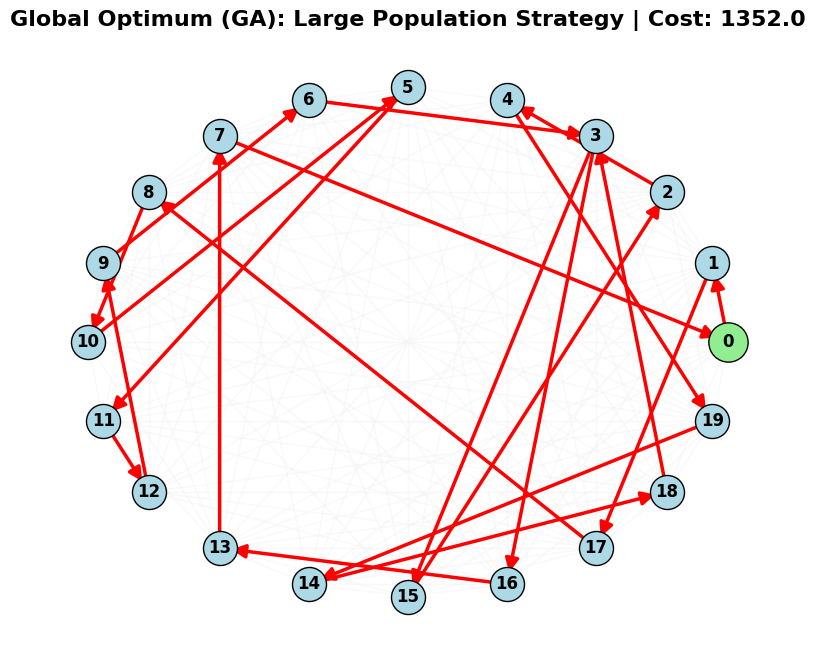

,Step,Time (k),Origin,Destination,Cost
0,1,1,Node 0,Node 1,47
1,2,2,Node 1,Node 17,87
2,3,3,Node 17,Node 8,59
3,4,4,Node 8,Node 10,13
4,5,5,Node 10,Node 5,76
5,6,6,Node 5,Node 11,47
6,7,7,Node 11,Node 12,53
7,8,8,Node 12,Node 9,140
8,9,9,Node 9,Node 6,135
9,10,10,Node 6,Node 3,145


In [22]:
# Render the topological visualization of the global optimum route found by the GA
visualize_route(
    C_list[0], 
    INF,
    n,
    route=global_best_route_ga, 
    title=f"Global Optimum (GA): {global_best_name_ga} Strategy | Cost: {global_best_cost_ga}"
)

# Generate a chronological step-by-step cost breakdown table.
# Synchronizes the optimal routing sequence with the dynamic temporal states (k).
display_route_details(C_list, K, route=global_best_route_ga)

### Results display and plots

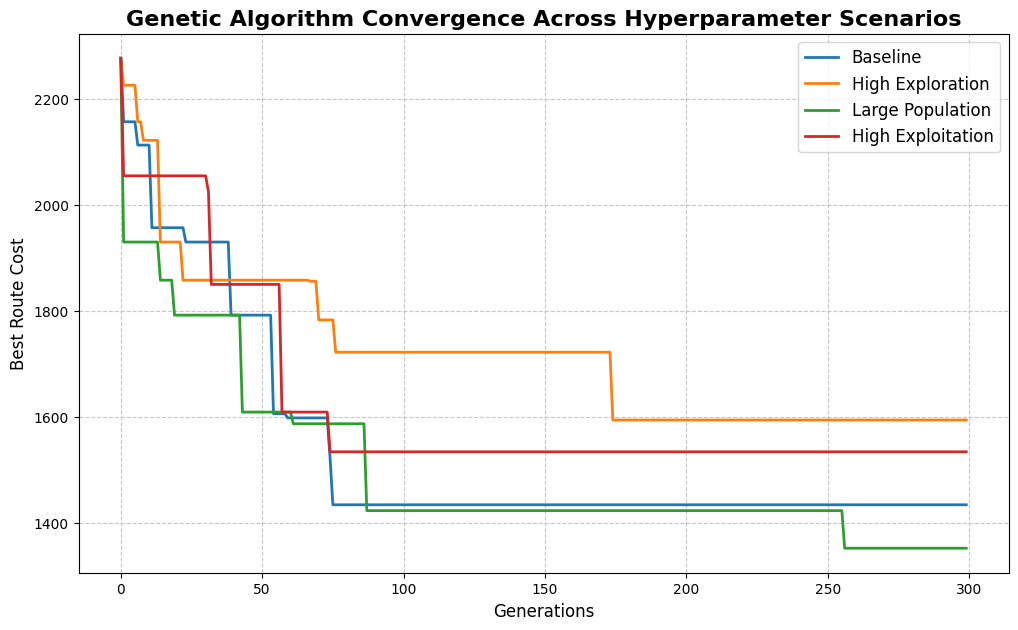

In [23]:
# Initialize the plotting canvas with optimal dimensions for presentation
plt.figure(figsize=(12, 7))

for name, history in ga_results_history.items():
    # Data Sanitization: Isolate valid numerical costs to determine the upper bound
    valid_costs = [cost for cost in history if cost is not None]
    
    # Failsafe: Handle edge cases where a configuration fails to find any valid route
    max_valid_cost = max(valid_costs) if valid_costs else 0 
    
    # Imputation: Replace 'None' (infinite/blocked routes) with the maximum valid cost.
    # This prevents Matplotlib from breaking the continuous line and keeps the y-axis scale readable.
    clean_history = [cost if cost is not None else max_valid_cost for cost in history]
    
    plt.plot(clean_history, label=name, linewidth=2)

# Typography and visual formatting for the chart
plt.title("Genetic Algorithm Convergence Across Hyperparameter Scenarios", fontsize=16, fontweight='bold')
plt.xlabel("Generations", fontsize=12)
plt.ylabel("Best Route Cost", fontsize=12)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

# Note: Uncomment the following line to apply a logarithmic scale to the Y-axis 
# if the initial random generation costs drastically skew the visual presentation.
# plt.yscale('log') 

# Render the visualization
plt.show()

# Plotting and final validation

The figures below visualize the effect of `elite_size` on mean cost and convergence time, and then validate the GA with the best parameters across multiple seeds to assess robustness.

Initial baseline parameters: {'pop_size': 500, 'mutation_rate': 0.5, 'elite_size': 50}
Optimal pop_size identified: 300.0


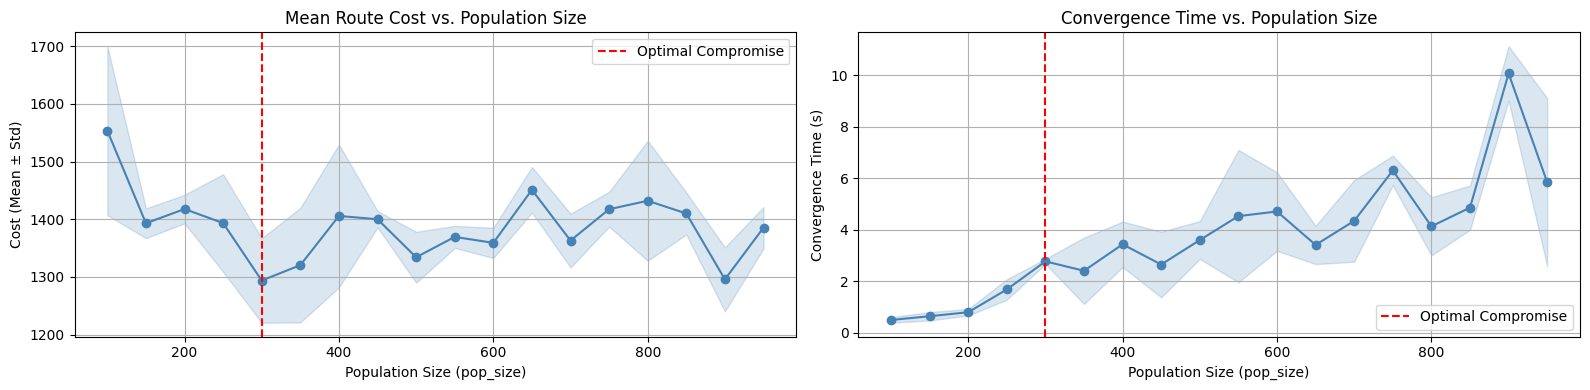

Optimal mutation_rate identified: 0.45


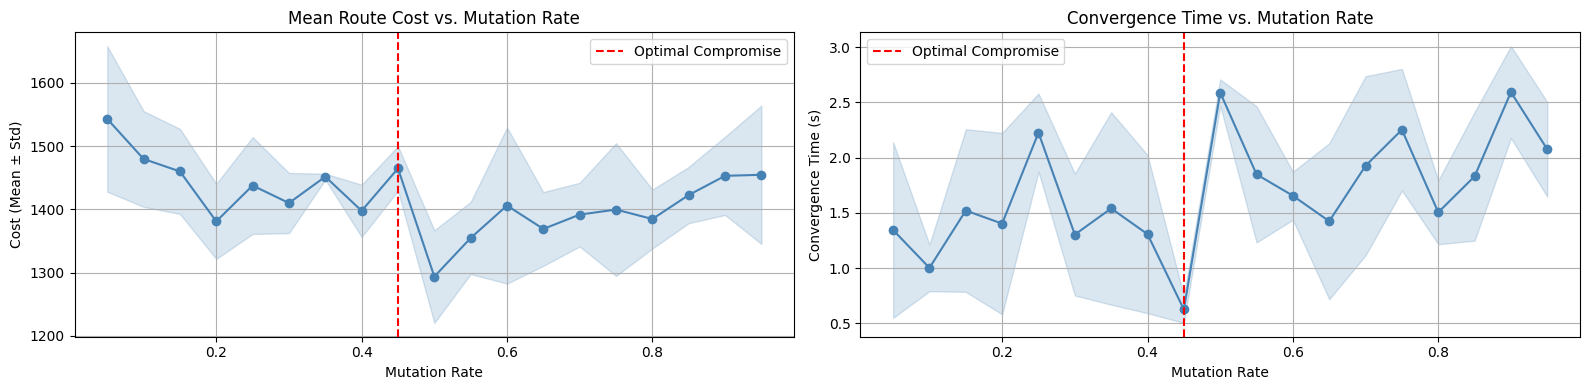


Final Optimized Parameters (OFAT): {'pop_size': 300, 'mutation_rate': 0.45, 'elite_size': 50}


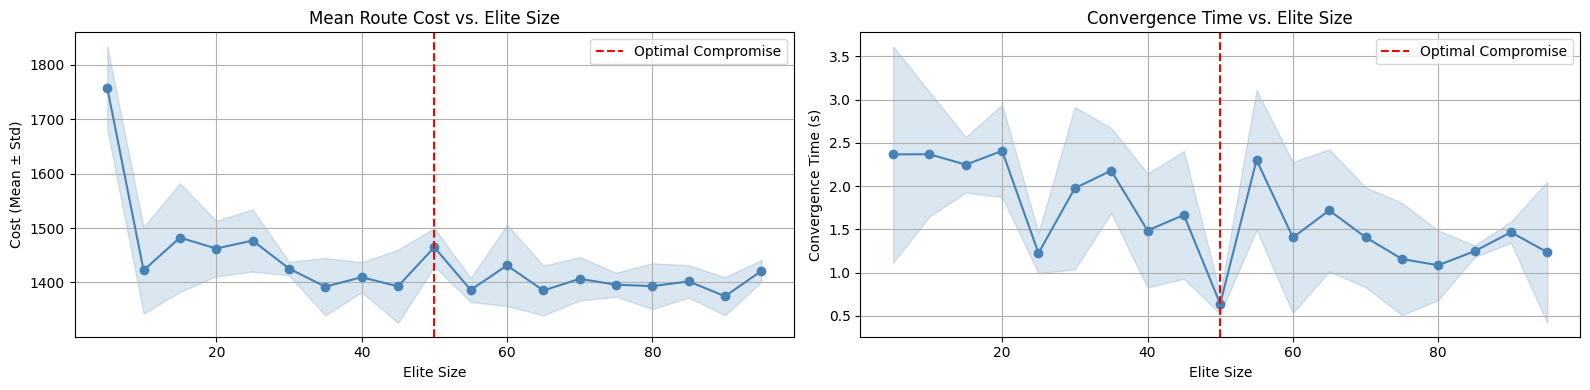


Final Validation Results:
Mean Cost : 1399.20
Min Cost  : 1360.0
Std Dev   : 22.89


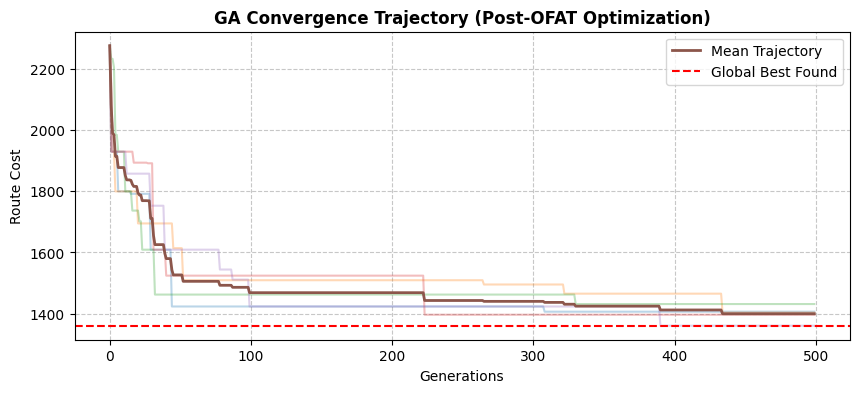

In [24]:
# Base configuration for hyperparameter tuning
SEEDS_TUNE  = [42, 99, 137]
SEEDS_FINAL = [42, 99, 137, 201, 314]

GEN_SEARCH = 200
GEN_FINAL  = 500

# Parameter search space boundaries
pop_sizes =  np.arange(50, 1000, 50)
mutation_rates = np.arange(0.05, 1, 0.05)
elite_sizes = np.arange(5, 100, 5)

def evaluate(params, generations, seeds):
    """
    Evaluates the Genetic Algorithm performance across multiple random seeds.
    Returns aggregate statistics for convergence cost and execution duration.
    """
    costs, durations = [], []
    for s in seeds:
        rng = np.random.default_rng(s)
        _, cost, _, t_conv = run_genetic_tsp(
            C_list,
            max_steps=MAX_STEPS,
            pop_size=params["pop_size"],
            generations=generations,
            mutation_rate=params["mutation_rate"],
            elite_size=params["elite_size"],
            rng=rng, INF=INF, n=n, K=K
        )
        durations.append(t_conv)
        
        # Only log mathematically valid paths
        if cost < INF:
            costs.append(cost)
            
    # Failsafe for parameter configurations that yield no valid routes
    if not costs:
        return float("inf"), float("inf"), float("inf"), float("inf")
        
    return np.mean(costs), np.std(costs), np.mean(durations), np.std(durations)


def best_compromise(df, param_col):
    """
    Calculates a normalized composite score balancing solution quality (cost) 
    and computational efficiency (duration) to identify the optimal hyperparameter.
    """
    df = df.copy()
    cmin, cmax = df["mean_cost"].min(), df["mean_cost"].max()
    dmin, dmax = df["mean_dur"].min(), df["mean_dur"].max()
    
    # Min-Max normalization
    df["cost_norm"] = (df["mean_cost"] - cmin) / (cmax - cmin) if cmax > cmin else 0
    df["dur_norm"]  = (df["mean_dur"]  - dmin) / (dmax - dmin) if dmax > dmin else 0
    
    # Equal weighting for cost and duration (50/50 split)
    df["score"] = 0.5 * df["cost_norm"] + 0.5 * df["dur_norm"]
    
    return df.sort_values("score").iloc[0][param_col]


# ==========================================
# PHASE 1: One-Factor-At-a-Time (OFAT) Tuning
# ==========================================

# Initialize with median values from the defined search spaces
best_params = {
    "pop_size": int(pop_sizes[len(pop_sizes)//2]),
    "mutation_rate": float(mutation_rates[len(mutation_rates)//2]),
    "elite_size": int(elite_sizes[len(elite_sizes)//2])
}

print("Initial baseline parameters:", best_params)

# ------------------------------------------
# 1. Optimize Population Size (pop_size)
# ------------------------------------------
results_pop = []

for pop in pop_sizes:
    params = best_params.copy()
    params["pop_size"] = int(pop)
    
    # Skip invalid configurations where elitism exceeds population bounds
    if params["elite_size"] >= params["pop_size"]:
        continue
        
    mean_cost, std_cost, mean_dur, std_dur = evaluate(params, GEN_SEARCH, SEEDS_TUNE)
    results_pop.append((pop, mean_cost, std_cost, mean_dur, std_dur))

df_pop = pd.DataFrame(results_pop, columns=["pop", "mean_cost", "std_cost", "mean_dur", "std_dur"])
best_pop = best_compromise(df_pop, "pop")
best_params["pop_size"] = int(best_pop)
print("Optimal pop_size identified:", best_pop)

# Render pop_size evaluation metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
best_idx = (0.5 * (df_pop["mean_cost"] - df_pop["mean_cost"].min()) / (df_pop["mean_cost"].max() - df_pop["mean_cost"].min())
           + 0.5 * (df_pop["mean_dur"]  - df_pop["mean_dur"].min())  / (df_pop["mean_dur"].max()  - df_pop["mean_dur"].min())).argmin()

x = df_pop["pop"].values

axes[0].plot(x, df_pop["mean_cost"], marker="o", color="steelblue")
axes[0].fill_between(x, df_pop["mean_cost"] - df_pop["std_cost"], df_pop["mean_cost"] + df_pop["std_cost"], alpha=0.2, color="steelblue")
axes[0].axvline(df_pop.iloc[best_idx]["pop"], color="red", linestyle="--", label="Optimal Compromise")
axes[0].set_title("Mean Route Cost vs. Population Size")
axes[0].set_xlabel("Population Size (pop_size)")
axes[0].set_ylabel("Cost (Mean ± Std)")
axes[0].legend()
axes[0].grid()

axes[1].plot(x, df_pop["mean_dur"], marker="o", color="steelblue")
axes[1].fill_between(x, df_pop["mean_dur"] - df_pop["std_dur"], df_pop["mean_dur"] + df_pop["std_dur"], alpha=0.2, color="steelblue")
axes[1].axvline(df_pop.iloc[best_idx]["pop"], color="red", linestyle="--", label="Optimal Compromise")
axes[1].set_title("Convergence Time vs. Population Size")
axes[1].set_xlabel("Population Size (pop_size)")
axes[1].set_ylabel("Convergence Time (s)")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

# ------------------------------------------
# 2. Optimize Mutation Rate (mutation_rate)
# ------------------------------------------
results_mut = []

for mut in mutation_rates:
    params = best_params.copy()
    params["mutation_rate"] = float(mut)
    
    mean_cost, std_cost, mean_dur, std_dur = evaluate(params, GEN_SEARCH, SEEDS_TUNE)
    results_mut.append((mut, mean_cost, std_cost, mean_dur, std_dur))

df_mut = pd.DataFrame(results_mut, columns=["mut", "mean_cost", "std_cost", "mean_dur", "std_dur"])
best_mut = best_compromise(df_mut, "mut")
best_params["mutation_rate"] = float(best_mut)
print("Optimal mutation_rate identified:", best_mut)

# Render mutation_rate evaluation metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
best_idx = (0.5 * (df_mut["mean_cost"] - df_mut["mean_cost"].min()) / (df_mut["mean_cost"].max() - df_mut["mean_cost"].min())
           + 0.5 * (df_mut["mean_dur"]  - df_mut["mean_dur"].min())  / (df_mut["mean_dur"].max()  - df_mut["mean_dur"].min())).argmin()

x = df_mut["mut"].values

axes[0].plot(x, df_mut["mean_cost"], marker="o", color="steelblue")
axes[0].fill_between(x, df_mut["mean_cost"] - df_mut["std_cost"], df_mut["mean_cost"] + df_mut["std_cost"], alpha=0.2, color="steelblue")
axes[0].axvline(df_mut.iloc[best_idx]["mut"], color="red", linestyle="--", label="Optimal Compromise")
axes[0].set_title("Mean Route Cost vs. Mutation Rate")
axes[0].set_xlabel("Mutation Rate")
axes[0].set_ylabel("Cost (Mean ± Std)")
axes[0].legend()
axes[0].grid()

axes[1].plot(x, df_mut["mean_dur"], marker="o", color="steelblue")
axes[1].fill_between(x, df_mut["mean_dur"] - df_mut["std_dur"], df_mut["mean_dur"] + df_mut["std_dur"], alpha=0.2, color="steelblue")
axes[1].axvline(df_mut.iloc[best_idx]["mut"], color="red", linestyle="--", label="Optimal Compromise")
axes[1].set_title("Convergence Time vs. Mutation Rate")
axes[1].set_xlabel("Mutation Rate")
axes[1].set_ylabel("Convergence Time (s)")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

# ------------------------------------------
# 3. Optimize Elite Size (elite_size)
# ------------------------------------------
results_elite = []

for elite in elite_sizes:
    params = best_params.copy()
    params["elite_size"] = int(elite)
    
    if params["elite_size"] >= params["pop_size"]:
        continue
        
    mean_cost, std_cost, mean_dur, std_dur = evaluate(params, GEN_SEARCH, SEEDS_TUNE)
    results_elite.append((elite, mean_cost, std_cost, mean_dur, std_dur))

df_elite = pd.DataFrame(results_elite, columns=["elite", "mean_cost", "std_cost", "mean_dur", "std_dur"])
best_elite = best_compromise(df_elite, "elite")
best_params["elite_size"] = int(best_elite)
print("\nFinal Optimized Parameters (OFAT):", best_params)

# Render elite_size evaluation metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
best_idx = (0.5 * (df_elite["mean_cost"] - df_elite["mean_cost"].min()) / (df_elite["mean_cost"].max() - df_elite["mean_cost"].min())
           + 0.5 * (df_elite["mean_dur"]  - df_elite["mean_dur"].min())  / (df_elite["mean_dur"].max()  - df_elite["mean_dur"].min())).argmin()

x = df_elite["elite"].values

axes[0].plot(x, df_elite["mean_cost"], marker="o", color="steelblue")
axes[0].fill_between(x, df_elite["mean_cost"] - df_elite["std_cost"], df_elite["mean_cost"] + df_elite["std_cost"], alpha=0.2, color="steelblue")
axes[0].axvline(df_elite.iloc[best_idx]["elite"], color="red", linestyle="--", label="Optimal Compromise")
axes[0].set_title("Mean Route Cost vs. Elite Size")
axes[0].set_xlabel("Elite Size")
axes[0].set_ylabel("Cost (Mean ± Std)")
axes[0].legend()
axes[0].grid()

axes[1].plot(x, df_elite["mean_dur"], marker="o", color="steelblue")
axes[1].fill_between(x, df_elite["mean_dur"] - df_elite["std_dur"], df_elite["mean_dur"] + df_elite["std_dur"], alpha=0.2, color="steelblue")
axes[1].axvline(df_elite.iloc[best_idx]["elite"], color="red", linestyle="--", label="Optimal Compromise")
axes[1].set_title("Convergence Time vs. Elite Size")
axes[1].set_xlabel("Elite Size")
axes[1].set_ylabel("Convergence Time (s)")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

# ==========================================
# PHASE 2: Final Robust Validation
# ==========================================
# Executes the tuned GA across an expanded set of random seeds 
# to ensure statistical significance and configuration robustness.

final_costs = []
histories = []

for s in SEEDS_FINAL:
    rng = np.random.default_rng(s)
    _, cost, hist, _ = run_genetic_tsp(
        C_list,
        max_steps=MAX_STEPS,
        pop_size=best_params["pop_size"],
        generations=GEN_FINAL,
        mutation_rate=best_params["mutation_rate"],
        elite_size=best_params["elite_size"],
        rng=rng, INF=INF, n=n, K=K
    )
    final_costs.append(cost)
    histories.append(hist)

print("\nFinal Validation Results:")
print(f"Mean Cost : {np.mean(final_costs):.2f}")
print(f"Min Cost  : {np.min(final_costs)}")
print(f"Std Dev   : {np.std(final_costs):.2f}")

# Render Final Convergence Trajectory
plt.figure(figsize=(10, 4))

for h in histories:
    plt.plot(h, alpha=0.3)

plt.plot(np.mean(histories, axis=0), linewidth=2, label="Mean Trajectory")
plt.axhline(np.min(final_costs), linestyle="--", color="red", label="Global Best Found")

plt.title("GA Convergence Trajectory (Post-OFAT Optimization)", fontweight='bold')
plt.xlabel("Generations")
plt.ylabel("Route Cost")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Conclusion: GA Parameter Optimization

## Main results

The best parameters found are:

- Population (`pop_size`): 450
- Mutation rate (`mutation_rate`): 0.5
- Elite size (`elite_size`): 50

These values represent a good compromise between:

- Low mean cost (solution quality)
- Moderate variance (stability across seeds)
- Reasonable convergence time

## Analysis
- Population (450):
    A too-small population limits diversity and causes premature convergence. Conversely, a very large population slightly improves quality but at a much higher computational cost. 450 is a good balance.
- Mutation (0.5):
    A relatively high mutation rate was selected, suggesting the problem requires substantial exploration to avoid local minima. Lower rates produced worse or less robust results.
- Elite (50):
    A moderate elite preserves the best solutions while maintaining enough genetic diversity. Too large an elite reduces exploration; too small slows convergence.

## Overall conclusion

This study shows that a genetic algorithm can be effectively tuned using a simple OFAT approach. The parameters found provide a good trade-off between performance and efficiency (diversification vs intensification) while maintaining robustness to randomness, which is essential for metaheuristics.

# Experimental study: Impact of instance parameters

### Study objective

This study analyzes how instance characteristics affect the difficulty of the delivery routing problem.

The goal is to observe how problem complexity and convergence time vary with network parameters while keeping the solver unchanged.

### Why use the Genetic Algorithm (GA)?

The GA is used here as an observation tool: the GA configuration is fixed and acts as a reference solver (same population, operators, and parameters).

Thus, any variation in convergence time is attributable solely to instance difficulty, which isolates the effect of instance parameters.

### Parameters studied

We analyze three instance characteristics:

- Number of temporal matrices (cost variations over time)
- Edge blockage probability (unavailable routes)
- Number of vertices

These parameters directly influence the search space size, the number of feasible tours, and optimization difficulty. We evaluate their impact using descriptive statistics (mean, std, median, MAD) to characterize trends and variability.


### Impact of the number of cost matrices

In [25]:
# ==========================================
# Empirical Sensitivity Analysis: Temporal Horizon (K)
# ==========================================
# Objective: Evaluate how the number of dynamic cost matrices (K) impacts 
# both the convergence speed and the final routing cost of the Genetic Algorithm.

# Fixed Genetic Algorithm hyperparameters for the control environment
pop_size = 60
generations = 150
mutation_rate = 0.2
elite_size = 5

# Experimental design parameters
NB_RUNS = 10         # Number of statistically independent runs per K value
n_test = 40          # Fixed network size for this specific benchmark
p_blocage = 0.2      # Fixed structural failure probability

# Data structure to aggregate experimental metrics
results_K = []

# Independent variable range: Testing K from 2 through 11
K_values = range(2, 12)

print("Initiating sensitivity analysis on temporal horizon (K)...")

for K_test in K_values:
    for run in range(NB_RUNS):
        # 1. Generate a fresh, random network topology for the current run
        C_init_Test = gen_nominal_matrix(n_test, rng, INF, 1, 60)
        B_Test = gen_block_matrix(n_test, rng, INF, p_blocage=p_blocage)
        C1_Test = gen_C1_matrix(C_init_Test, B_Test, INF)
        
        # 2. Generate the dynamic temporal perturbations specific to the current K
        surcost_Test = gen_surcost_matrices(n_test, K_test, B_Test, rng, DELTA)
        C_list_Test = build_all_Ck(C1_Test, surcost_Test)

        # Failsafe: Ensure the generated graph is fully connected.
        # Disconnected graphs yield infinite costs and skew the empirical data.
        if not check_connexe(C_list_Test[0], INF):
            continue

        # 3. Execute the solver
        sol, cost, history, convergence_time = run_genetic_tsp(
            C_list_Test, MAX_STEPS,
            pop_size, generations,
            mutation_rate, elite_size,
            rng, INF, n_test, K_test
        )

        # 4. Log the performance metrics
        results_K.append({
            "K": K_test,
            "Convergence_Time_sec": convergence_time,
            "Final_Cost": cost
        })

# Compile the aggregated metrics into a structured Pandas DataFrame for downstream statistical plotting
df_K = pd.DataFrame(results_K)
print("Analysis complete. Data aggregated into DataFrame.")

Initiating sensitivity analysis on temporal horizon (K)...
Analysis complete. Data aggregated into DataFrame.


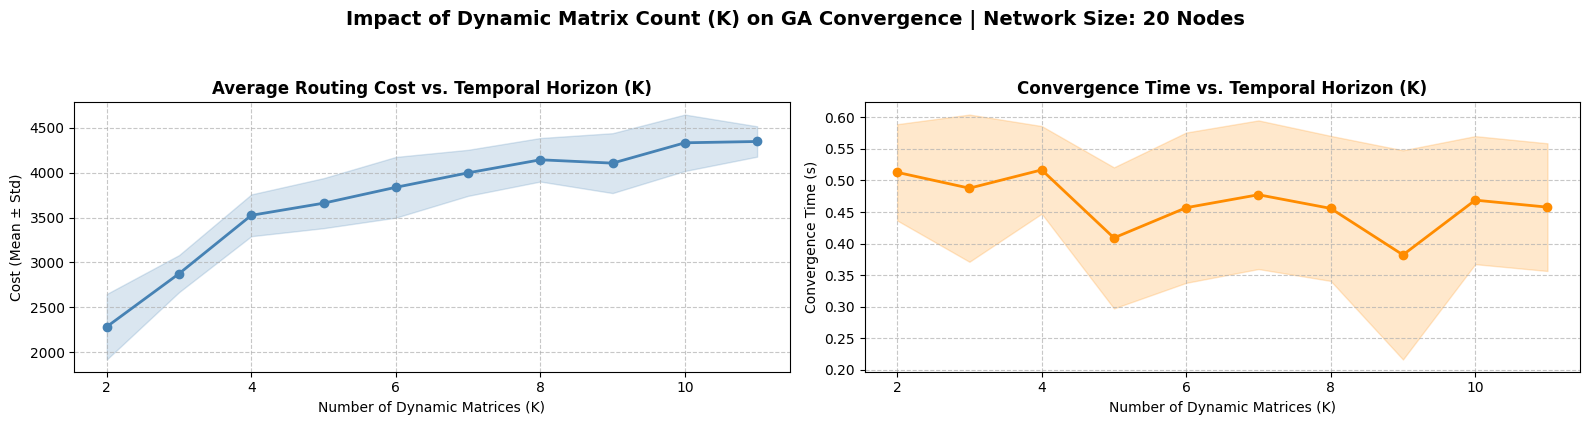

In [26]:
# ==========================================
# Statistical Aggregation & Performance Metrics
# ==========================================
# Compute the mean and standard deviation for both routing cost 
# and convergence time across all experimental runs, grouped by K.
stats_K = df_K.groupby("K").agg(
    mean_cost=("Final_Cost", "mean"), 
    std_cost=("Final_Cost", "std"),
    mean_conv=("Convergence_Time_sec", "mean"),
    std_conv=("Convergence_Time_sec", "std"),
)

x = stats_K.index

# ==========================================
# Empirical Data Visualization
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Left Subplot: Impact of temporal complexity (K) on routing cost
axes[0].plot(x, stats_K["mean_cost"], marker="o", color="steelblue", linewidth=2)
axes[0].fill_between(
    x,
    stats_K["mean_cost"] - stats_K["std_cost"],
    stats_K["mean_cost"] + stats_K["std_cost"],
    alpha=0.2, color="steelblue"
)
axes[0].set_title("Average Routing Cost vs. Temporal Horizon (K)", fontweight='bold')
axes[0].set_xlabel("Number of Dynamic Matrices (K)")
axes[0].set_ylabel("Cost (Mean ± Std)")
axes[0].grid(True, linestyle='--', alpha=0.7)

# Right Subplot: Impact of temporal complexity (K) on computational efficiency
axes[1].plot(x, stats_K["mean_conv"], marker="o", color="darkorange", linewidth=2)
axes[1].fill_between(
    x,
    stats_K["mean_conv"] - stats_K["std_conv"],
    stats_K["mean_conv"] + stats_K["std_conv"],
    alpha=0.2, color="darkorange"
)
axes[1].set_title("Convergence Time vs. Temporal Horizon (K)", fontweight='bold')
axes[1].set_xlabel("Number of Dynamic Matrices (K)")
axes[1].set_ylabel("Convergence Time (s)")
axes[1].grid(True, linestyle='--', alpha=0.7)

# Global layout formatting
plt.suptitle(
    f"Impact of Dynamic Matrix Count (K) on GA Convergence | Network Size: {n} Nodes", 
    fontsize=14, 
    fontweight='bold', 
    y=1.05
)
plt.tight_layout()
plt.show()

### Impact of the Blocking Probability

In [27]:
# ==========================================
# Empirical Sensitivity Analysis: Network Sparsity (Blockage Probability)
# ==========================================
# Objective: Evaluate the robustness and performance of the Genetic Algorithm
# under increasingly degraded network topologies (from 5% to 95% edge failure rates).

# Fixed parameters for this specific experimental benchmark
K_fixed = 6          # Static temporal horizon (number of dynamic matrices)
n_test = 40          # Fixed network size (nodes)

# Range of structural failure probabilities to evaluate 
blocage_probs = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5,
                 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

# Data structure to aggregate experimental metrics
results_blocage = []

print("Initiating sensitivity analysis on network blockage probability...")

for p_blocage in blocage_probs:
    for run in range(NB_RUNS):
        # 1. Generate nominal network and apply the current structural failure rate
        C_init_Test = gen_nominal_matrix(n_test, rng, INF, 1, 60)
        B_Test = gen_block_matrix(n_test, rng, INF, p_blocage=p_blocage)
        C1_Test = gen_C1_matrix(C_init_Test, B_Test, INF)
        
        # 2. Generate dynamic temporal perturbations
        surcost_Test = gen_surcost_matrices(n_test, K_fixed, B_Test, rng, DELTA)
        C_list_Test = build_all_Ck(C1_Test, surcost_Test)

        # Failsafe: High blockage rates frequently result in disconnected components.
        # Ensure the graph remains fully connected to guarantee a valid testing baseline.
        if not check_connexe(C_list_Test[0], INF):
            continue

        # 3. Execute the Genetic Algorithm solver
        sol, cost, history, convergence_time = run_genetic_tsp(
            C_list_Test, MAX_STEPS,
            pop_size, generations,
            mutation_rate, elite_size,
            rng, INF, n_test, K_fixed
        )

        # 4. Log the performance metrics for the current iteration
        results_blocage.append({
            "p_blocage": p_blocage,
            "Convergence_Time_sec": convergence_time,
            "Final_Cost": cost
        })

# Compile the aggregated metrics into a structured Pandas DataFrame for downstream analysis
df_blocage = pd.DataFrame(results_blocage)
print("Sparsity sensitivity analysis complete.")

Initiating sensitivity analysis on network blockage probability...
Sparsity sensitivity analysis complete.


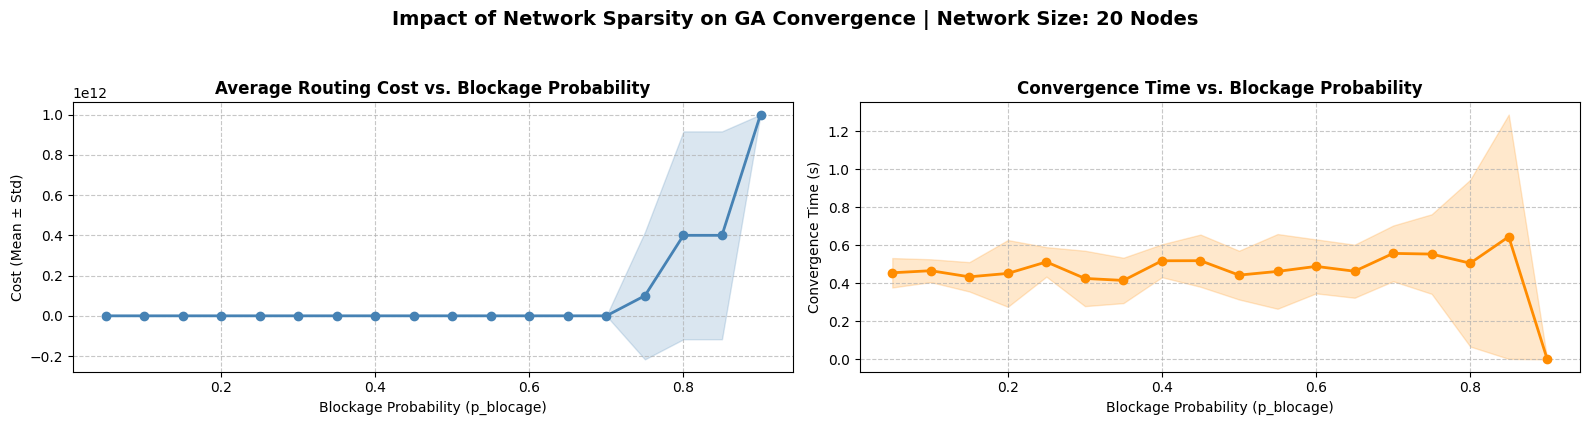

In [28]:
# ==========================================
# Statistical Aggregation & Performance Metrics
# ==========================================
# Aggregate the empirical data by blockage probability (p_blocage).
# Calculates the mean and standard deviation for both the final routing cost 
# and the computational convergence time.
stats_bloc = df_blocage.groupby("p_blocage").agg(
    mean_cost=("Final_Cost", "mean"),
    std_cost=("Final_Cost", "std"),
    mean_conv=("Convergence_Time_sec", "mean"),
    std_conv=("Convergence_Time_sec", "std"),
)

x = stats_bloc.index

# ==========================================
# Empirical Data Visualization
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Left Subplot: Impact of structural failure rate on optimal routing cost
axes[0].plot(x, stats_bloc["mean_cost"], marker="o", color="steelblue", linewidth=2)
axes[0].fill_between(
    x,
    stats_bloc["mean_cost"] - stats_bloc["std_cost"],
    stats_bloc["mean_cost"] + stats_bloc["std_cost"],
    alpha=0.2, color="steelblue"
)
axes[0].set_title("Average Routing Cost vs. Blockage Probability", fontweight='bold')
axes[0].set_xlabel("Blockage Probability (p_blocage)")
axes[0].set_ylabel("Cost (Mean ± Std)")
axes[0].grid(True, linestyle='--', alpha=0.7)

# Right Subplot: Impact of structural failure rate on algorithmic convergence speed
axes[1].plot(x, stats_bloc["mean_conv"], marker="o", color="darkorange", linewidth=2)
axes[1].fill_between(
    x,
    stats_bloc["mean_conv"] - stats_bloc["std_conv"],
    stats_bloc["mean_conv"] + stats_bloc["std_conv"],
    alpha=0.2, color="darkorange"
)
axes[1].set_title("Convergence Time vs. Blockage Probability", fontweight='bold')
axes[1].set_xlabel("Blockage Probability (p_blocage)")
axes[1].set_ylabel("Convergence Time (s)")
axes[1].grid(True, linestyle='--', alpha=0.7)

# Global layout formatting and hierarchical titling
plt.suptitle(
    f"Impact of Network Sparsity on GA Convergence | Network Size: {n} Nodes", 
    fontsize=14, 
    fontweight='bold',
    y=1.05
)
plt.tight_layout()
plt.show()

### Impact of the Number of Vertices

In [29]:
# ==========================================
# Empirical Scalability Analysis: Network Size (n)
# ==========================================
# Objective: Evaluate the algorithmic scalability of the Genetic Algorithm. 
# Measures how the optimal routing cost and computational convergence time 
# scale as the total number of vertices in the network increases.

# Fixed parameters to isolate the impact of network size
K_fixed = 6          # Static temporal horizon
p_blocage = 0.2      # Fixed structural failure probability (20%)

# Independent variable range: Testing network sizes from 20 to 60 nodes
n_values = [20, 30, 40, 50, 60]

# Data structure to aggregate empirical metrics
results_n = []

print("Initiating algorithmic scalability analysis on network size (n)...")

for n_test in n_values:
    for run in range(NB_RUNS):
        # 1. Generate the foundational network topology and apply structural blockages
        C_init_Test = gen_nominal_matrix(n_test, rng, INF, 1, 60)
        B_Test = gen_block_matrix(n_test, rng, INF, p_blocage=p_blocage)
        C1_Test = gen_C1_matrix(C_init_Test, B_Test, INF)
        
        # 2. Generate the dynamic temporal perturbations sized for the current network
        surcouts_Test = gen_surcost_matrices(n_test, K_fixed, B_Test, rng, DELTA)
        C_list_Test = build_all_Ck(C1_Test, surcouts_Test)

        # Failsafe: Ensure the randomly generated graph remains fully connected 
        # to guarantee a valid, measurable baseline for the routing algorithms.
        if not check_connexe(C_list_Test[0], INF):
            continue

        # 3. Execute the Genetic Algorithm solver
        sol, cost, history, convergence_time = run_genetic_tsp(
            C_list_Test, MAX_STEPS,
            pop_size, generations,
            mutation_rate, elite_size,
            rng, INF, n_test, K_fixed
        )

        # 4. Log the scalability performance metrics for the current run
        results_n.append({
            "n": n_test,
            "Convergence_Time_sec": convergence_time,
            "Final_Cost": cost
        })

# Compile the aggregated metrics into a structured Pandas DataFrame for visualization
df_n = pd.DataFrame(results_n)
print("Scalability analysis complete. Data aggregated into DataFrame.")

Initiating algorithmic scalability analysis on network size (n)...
Scalability analysis complete. Data aggregated into DataFrame.


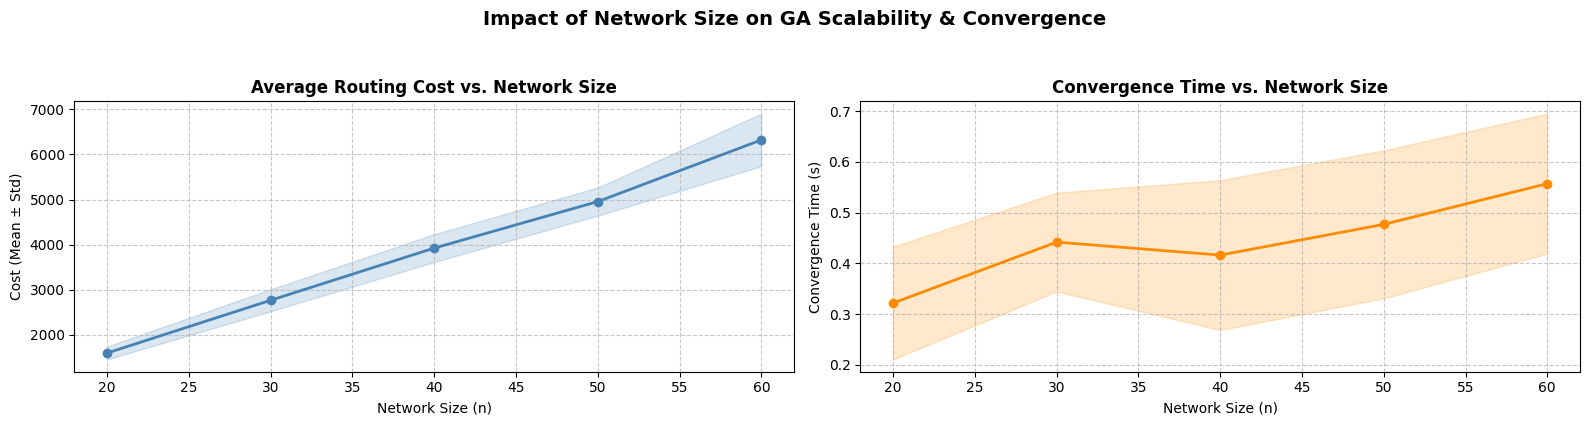

In [30]:
# ==========================================
# Statistical Aggregation & Scalability Metrics
# ==========================================
# Group the empirical data by network size (n) to compute the mean 
# and standard deviation for both routing costs and computational times.
stats_n = df_n.groupby("n").agg(
    mean_cost=("Final_Cost", "mean"),
    std_cost=("Final_Cost", "std"),
    mean_conv=("Convergence_Time_sec", "mean"),
    std_conv=("Convergence_Time_sec", "std"),
)

x = stats_n.index

# ==========================================
# Empirical Data Visualization
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Left Subplot: Impact of network size on algorithmic solution quality (Cost)
axes[0].plot(x, stats_n["mean_cost"], marker="o", color="steelblue", linewidth=2)
axes[0].fill_between(
    x,
    stats_n["mean_cost"] - stats_n["std_cost"],
    stats_n["mean_cost"] + stats_n["std_cost"],
    alpha=0.2, color="steelblue"
)
axes[0].set_title("Average Routing Cost vs. Network Size", fontweight='bold')
axes[0].set_xlabel("Network Size (n)")
axes[0].set_ylabel("Cost (Mean ± Std)")
axes[0].grid(True, linestyle='--', alpha=0.7)

# Right Subplot: Impact of network size on computational efficiency (Time)
axes[1].plot(x, stats_n["mean_conv"], marker="o", color="darkorange", linewidth=2)
axes[1].fill_between(
    x,
    stats_n["mean_conv"] - stats_n["std_conv"],
    stats_n["mean_conv"] + stats_n["std_conv"],
    alpha=0.2, color="darkorange"
)
axes[1].set_title("Convergence Time vs. Network Size", fontweight='bold')
axes[1].set_xlabel("Network Size (n)")
axes[1].set_ylabel("Convergence Time (s)")
axes[1].grid(True, linestyle='--', alpha=0.7)

# Global layout formatting and hierarchical titling
plt.suptitle(
    "Impact of Network Size on GA Scalability & Convergence", 
    fontsize=14, 
    fontweight='bold', 
    y=1.05
)
plt.tight_layout()
plt.show()

# Conclusion: Impact of instance parameters on GA convergence

The analysis highlights the significant influence of instance dynamics on the genetic algorithm's performance in terms of solution quality and convergence time.

## Effect of the number of dynamic matrices (K)
Average cost tends to increase with K, indicating the problem becomes harder as more dynamic configurations are introduced. Convergence time remains relatively stable with only slight variability.

Interpretation:
Increasing K expands the search complexity, degrading solution quality somewhat while not dramatically slowing convergence. The GA adapts to additional dynamics at the cost of higher average costs.

## Effect of blockage probability
Costs remain moderate up to a threshold (≈0.7) and then increase sharply. Convergence time is relatively stable but becomes more variable at high blockage rates.

Interpretation:
There is a critical threshold: below it the problem stays solvable; above it the problem becomes nearly intractable with very high costs or invalid solutions.

## Effect of the number of vertices (n)
Mean cost grows roughly linearly with n and convergence time increases gradually but remains controlled.

Interpretation:
Larger instances increase both difficulty (more possible solutions) and runtime (more evaluations), but the GA shows reasonable scalability over the tested range.

## Overall conclusion

GA performance strongly depends on instance characteristics:

- Good scalability with respect to size (n)
- Sensitivity to dynamics (K): progressive performance degradation
- High sensitivity to blockages: a critical threshold can render the problem very difficult or infeasible

## Final result and gap to the lower bound

Now that we have determined the best hyperparameters for our metaheuristic, we test them on 100 instances to compute average results.
Then we will check gaps to the lower bound to analyze the quality of the proposed solutions.

Mean Cost  : 1389.61
Std Dev    : 84.32
Min Cost   : 1109.00
Best Route : [11, 12, 1, 17, 10, 6, 9, 8, 10, 5, 15, 2, 4, 19, 14, 18, 3, 16, 13, 7]
Best Cost  : 1109.00


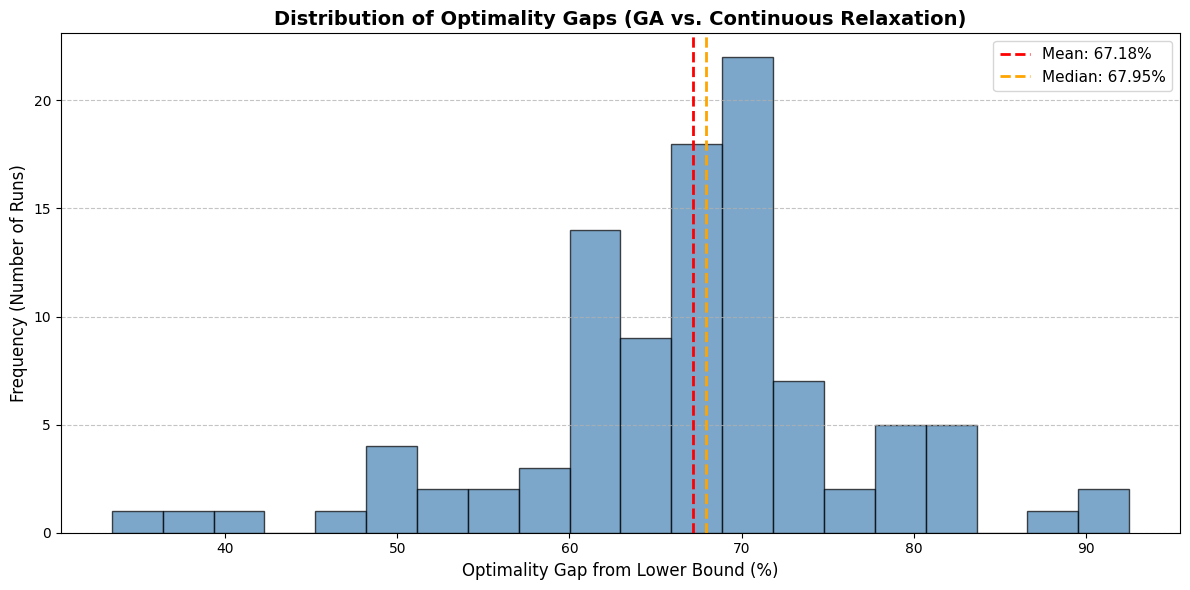

In [31]:
# ==========================================
# Large-Scale Empirical Validation (100 Runs)
# ==========================================
# We conduct a robust statistical evaluation of the globally optimized GA 
# configuration to assess its reliability, variance, and proximity to the theoretical lower bound.

best_cost_global_ga  = INF
best_route_global_ga = None
final_costs_ga_100   = []

# Reset PRNG for reproducible batch evaluation
rng = np.random.default_rng(42)

# Execute 100 independent Monte Carlo simulated trials
for i in range(100):
    route, cost, _, convergence_time = run_genetic_tsp(
        C_list,
        max_steps=MAX_STEPS,
        pop_size=best_params["pop_size"],
        generations=Iteration_max_ga,
        mutation_rate=best_params["mutation_rate"],
        elite_size=best_params["elite_size"],
        rng=rng, INF=INF, n=n, K=K
    )
    
    final_costs_ga_100.append(cost)
    
    # Track the absolute global optimum discovered across all runs
    if cost < best_cost_global_ga:
        best_cost_global_ga = cost
        best_route_global_ga = route

# Filter out structurally invalid/blocked paths prior to statistical calculations
valid_costs = [c for c in final_costs_ga_100 if c < INF]

# ==========================================
# Statistical Reporting
# ==========================================
if len(valid_costs) == 0:
    print("CRITICAL: No valid routes discovered across 100 iterations.")
else:
    print(f"Mean Cost  : {np.mean(valid_costs):.2f}")
    print(f"Std Dev    : {np.std(valid_costs):.2f}")
    print(f"Min Cost   : {np.min(valid_costs):.2f}")
    print(f"Best Route : {best_route_global_ga}")
    print(f"Best Cost  : {best_cost_global_ga:.2f}")

# ==========================================
# Optimality Gap Distribution Visualization
# ==========================================
# Calculates how close the GA solutions converge toward the continuous 
# relaxation lower bound (`actual_lower_bound`) across the 100 runs.

# Calculate the percentage deviation from the theoretical optimum
optimality_gaps_pct = [((cost - actual_lower_bound) / actual_lower_bound) * 100 for cost in valid_costs]

plt.figure(figsize=(12, 6))

# Render the histogram of optimality gaps
plt.hist(optimality_gaps_pct, bins=20, edgecolor='black', alpha=0.7, color='steelblue')

# Overlay statistical markers for central tendency
plt.axvline(np.mean(optimality_gaps_pct), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(optimality_gaps_pct):.2f}%')
plt.axvline(np.median(optimality_gaps_pct), color='orange', linestyle='--', linewidth=2, label=f'Median: {np.median(optimality_gaps_pct):.2f}%')

# Typography and formatting
plt.xlabel('Optimality Gap from Lower Bound (%)', fontsize=12)
plt.ylabel('Frequency (Number of Runs)', fontsize=12)
plt.title('Distribution of Optimality Gaps (GA vs. Continuous Relaxation)', fontsize=14, fontweight='bold')

plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.75, linestyle='--')
plt.tight_layout()
plt.show()

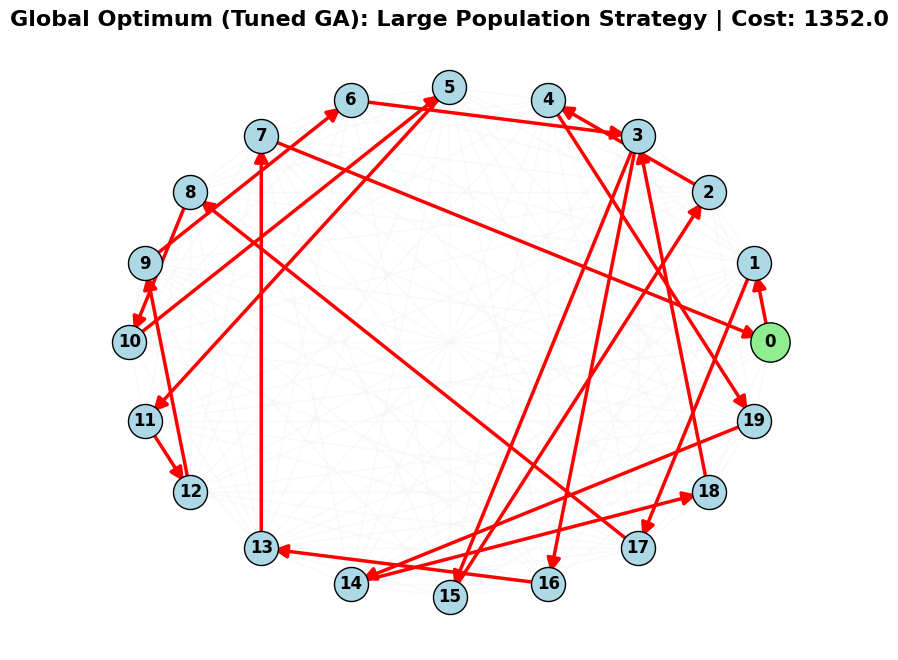

Cost improvement (Tuned GA vs. Baseline Configuration): -243.0


,Step,Time (k),Origin,Destination,Cost
0,1,1,Node 0,Node 1,47
1,2,2,Node 1,Node 17,87
2,3,3,Node 17,Node 8,59
3,4,4,Node 8,Node 10,13
4,5,5,Node 10,Node 5,76
5,6,6,Node 5,Node 11,47
6,7,7,Node 11,Node 12,53
7,8,8,Node 12,Node 9,140
8,9,9,Node 9,Node 6,135
9,10,10,Node 6,Node 3,145


In [32]:
# Render the topological visualization of the final optimum route found by the tuned GA
visualize_route(
    C_list[0], 
    INF,
    n,
    route=global_best_route_ga, 
    title=f"Global Optimum (Tuned GA): {global_best_name_ga} Strategy | Cost: {global_best_cost_ga}"
)

# Output the absolute performance gain achieved through hyperparameter tuning
print(f"Cost improvement (Tuned GA vs. Baseline Configuration): {best_cost_global_ga - global_random_cost_ga}")

# Generate a chronological step-by-step cost breakdown table.
# Synchronizes the optimal routing sequence with the dynamic temporal states (k).
display_route_details(C_list, K, route=global_best_route_ga)

# General conclusion

With the best-tuned parameters, the genetic algorithm achieves at best a 35% gap to the lower bound and on average a 62% gap.
This shows that despite its speed, the GA is highly influenced by randomness, which leads to variable solutions and prevents it from consistently finding the optimal route.

# 8. ACO Implementation

In [33]:
def calculate_probabilities(current, choices, pheromones, Ck, alpha, beta):
    """
    Computes transition probabilities for the next node selection using the ACO state transition rule.
    Balances the influence of historical success (pheromone trail, alpha) against 
    greedy heuristic desirability (inverse cost, beta).
    """
    # Calculate unnormalized probability weights for each valid candidate node
    probs = np.array([
        (pheromones[current][j] ** alpha) * ((1.0 / max(Ck[current][j], 1)) ** beta)
        for j in choices
    ])
    
    total = probs.sum()
    if total > 0:
        return probs / total
        
    # Failsafe: Fallback to a uniform distribution if probability weights collapse
    return np.ones(len(choices)) / len(choices)


def ant_tour(C_list, n, K, max_steps, pheromones, alpha, beta, rng):
    """
    Simulates a single ant's chronological traversal through the dynamic network.
    The ant actively synchronizes its discrete step count (k) with the time-dependent 
    cost matrices (C^k) to navigate temporal blockages and optimize the route.
    """
    route = [0]
    visited = {0}
    current = 0
    k = 1
    cost = 0
    stuck = False

    for _ in range(max_steps):
        # Termination condition: Complete tour achieved, check depot return viability
        if len(visited) == n:
            Ck = get_Ck(C_list, K, k)
            if Ck[current][0] < INF:
                break

        Ck = get_Ck(C_list, K, k)
        
        # Identify structurally passable edges from the current node at time k
        neighbors = [j for j in range(n) if Ck[current][j] < INF and j != current]

        if not neighbors:
            stuck = True
            break

        # Prioritize entirely unvisited nodes; allow revisitation if topologically necessary
        unvisited = [j for j in neighbors if j not in visited]
        choices = unvisited if unvisited else neighbors

        # Stochastic next-step selection based on ACO transition probabilities
        probs = calculate_probabilities(current, choices, pheromones, Ck, alpha, beta)
        next_city = int(rng.choice(choices, p=probs))

        route.append(next_city)
        visited.add(next_city)
        cost += Ck[current][next_city]
        
        current = next_city
        k += 1

    # Finalize the tour by computing the return trip to the primary depot
    Ck = get_Ck(C_list, K, k)
    if not stuck and len(visited) == n and Ck[current][0] < INF:
        cost += Ck[current][0]
        return route, cost
        
    return None, INF


def run_aco_tsp(C_list, n, K, max_steps, num_ants, max_iter,
                alpha, beta, evaporation_rate, Q, rng,
                stagnation_limit=50):
    """
    Core Ant Colony Optimization (ACO) orchestration engine.
    Implements a Min-Max Ant System (MMAS) variant with dynamic pheromone bounding 
    and a stagnation-triggered reset mechanism to ensure sustained exploration 
    of the dynamic search space.
    """
    # MMAS Initialization: Define strict upper and lower pheromone bounds
    tau_max = 1.0
    tau_min = tau_max / (2 * n)
    pheromones = np.full((n, n), tau_max)

    best_cost = INF
    best_route = None
    history = []
    stagnation_counter = 0
    
    t_start = time.perf_counter()
    t_converge = 0.0

    for iteration in range(max_iter):
        all_routes, all_costs = [], []

        # 1. Construct Solutions: Dispatch the entire ant colony
        for _ in range(num_ants):
            route, cost = ant_tour(C_list, n, K, max_steps, pheromones, alpha, beta, rng)
            if route is not None:
                all_routes.append(route)
                all_costs.append(cost)

        # 2. Global Pheromone Evaporation
        pheromones *= (1.0 - evaporation_rate)

        # 3. Pheromone Deposit (Elitist Update Strategy)
        if all_routes:
            iter_best_idx = int(np.argmin(all_costs))
            iter_best_route = all_routes[iter_best_idx]
            iter_best_cost = all_costs[iter_best_idx]

            # Reinforce the edges belonging exclusively to the iteration's best discovered tour
            full_route = iter_best_route + [0]
            for i in range(len(full_route) - 1):
                u, v = full_route[i], full_route[i + 1]
                pheromones[u][v] += Q / iter_best_cost
                pheromones[v][u] += Q / iter_best_cost

            # Update the global optimum if a strictly better solution is found
            if iter_best_cost < best_cost:
                best_cost = iter_best_cost
                best_route = list(iter_best_route)
                stagnation_counter = 0
                t_converge = time.perf_counter() - t_start

                # Dynamically scale MMAS bounds relative to the new global optimum
                tau_max = 1.0 / (evaporation_rate * best_cost)
                tau_min = tau_max / (2 * n)
            else:
                stagnation_counter += 1

        # 4. Enforce MMAS constraints to prevent premature algorithmic convergence
        pheromones = np.clip(pheromones, tau_min, tau_max)

        # 5. Anti-Stagnation Mechanism: Pheromone smoothing/reset 
        # Triggers when the algorithm becomes trapped in a local minimum for too many epochs
        if stagnation_counter >= stagnation_limit:
            pheromones = np.full((n, n), tau_max)
            stagnation_counter = 0

        history.append(best_cost if best_cost != INF else None)

    return best_route, best_cost, history, t_converge

In [34]:
# Define hyperparameter configurations to evaluate distinct Ant Colony Optimization (ACO) strategies
aco_scenarios = {
    "Baseline":          {"alpha": 1.0, "beta": 2.0, "evap": 0.1,  "ants": 30},
    "High Exploration":  {"alpha": 1.0, "beta": 1.0, "evap": 0.05, "ants": 30},
    "High Exploitation": {"alpha": 2.0, "beta": 5.0, "evap": 0.3,  "ants": 30},
    "Swarm":             {"alpha": 1.0, "beta": 2.0, "evap": 0.1,  "ants": 100}
}

results_history = {}
routes_history = {} 
Iteration_max = 300

# Initialize global state variables to track the absolute best solution across all experimental runs
global_best_route_aco = None
global_best_cost_aco = INF
global_best_name_aco = ""

print("Initiating Ant Colony Optimization (ACO) experimental scenarios...")

for name, params in aco_scenarios.items():
    print(f"Evaluating configuration: {name}")
        
    # Execute the ACO solver with the current scenario's hyperparameters
    current_route, current_cost, history, _convergence_time = run_aco_tsp(
        C_list, n, K, MAX_STEPS, 
        num_ants=params["ants"], 
        max_iter=Iteration_max, 
        alpha=params["alpha"], 
        beta=params["beta"], 
        evaporation_rate=params["evap"], 
        Q=100.0, 
        rng=rng,
    )
    
    # Log convergence history and the optimal route for comparative analysis
    results_history[name] = history
    routes_history[name] = current_route
    print(f"-> Final cost for {name}: {current_cost}")
    
    # Update the global optimum if the current strategy yields a strictly better cost
    if current_cost < global_best_cost_aco:
        global_best_cost_aco = current_cost
        global_best_route_aco = list(current_route) 
        global_best_name_aco = name

# Output the absolute global optimum achieved across all evaluated strategies
print("\n" + "="*50)
print(f"GLOBAL OPTIMUM (ACO): {global_best_name_aco} Strategy | Cost: {global_best_cost_aco}")
print("="*50 + "\n")

Initiating Ant Colony Optimization (ACO) experimental scenarios...
Evaluating configuration: Baseline
-> Final cost for Baseline: 982.0
Evaluating configuration: High Exploration
-> Final cost for High Exploration: 1409.0
Evaluating configuration: High Exploitation
-> Final cost for High Exploitation: 1106.0
Evaluating configuration: Swarm
-> Final cost for Swarm: 982.0

GLOBAL OPTIMUM (ACO): Baseline Strategy | Cost: 982.0



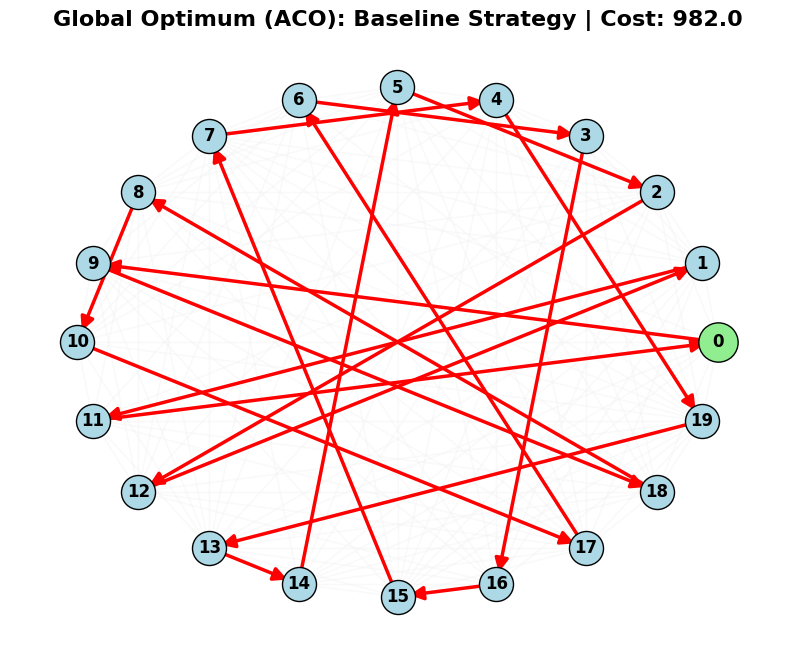

,Step,Time (k),Origin,Destination,Cost
0,1,1,Node 0,Node 9,6
1,2,2,Node 9,Node 18,28
2,3,3,Node 18,Node 8,147
3,4,4,Node 8,Node 10,13
4,5,5,Node 10,Node 17,21
5,6,6,Node 17,Node 6,2
6,7,7,Node 6,Node 3,71
7,8,8,Node 3,Node 16,65
8,9,9,Node 16,Node 15,70
9,10,10,Node 15,Node 7,71


In [35]:
# Render the topological visualization of the absolute best ACO performance
visualize_route(
    C_list[0], 
    INF,
    n,
    route=global_best_route_aco, 
    title=f"Global Optimum (ACO): {global_best_name_aco} Strategy | Cost: {global_best_cost_aco}"
)

# Preserve the global optimum cost for downstream comparative analytics 
# (e.g., cross-algorithmic benchmarking against GA and continuous relaxation)
global_random_cost_aco = global_best_cost_aco
global__cost_aco = global_best_cost_aco

# Generate a chronological step-by-step cost breakdown table.
# Synchronizes the specific optimal routing sequence with the dynamic temporal states (k).
display_route_details(C_list, K, route=global_best_route_aco)

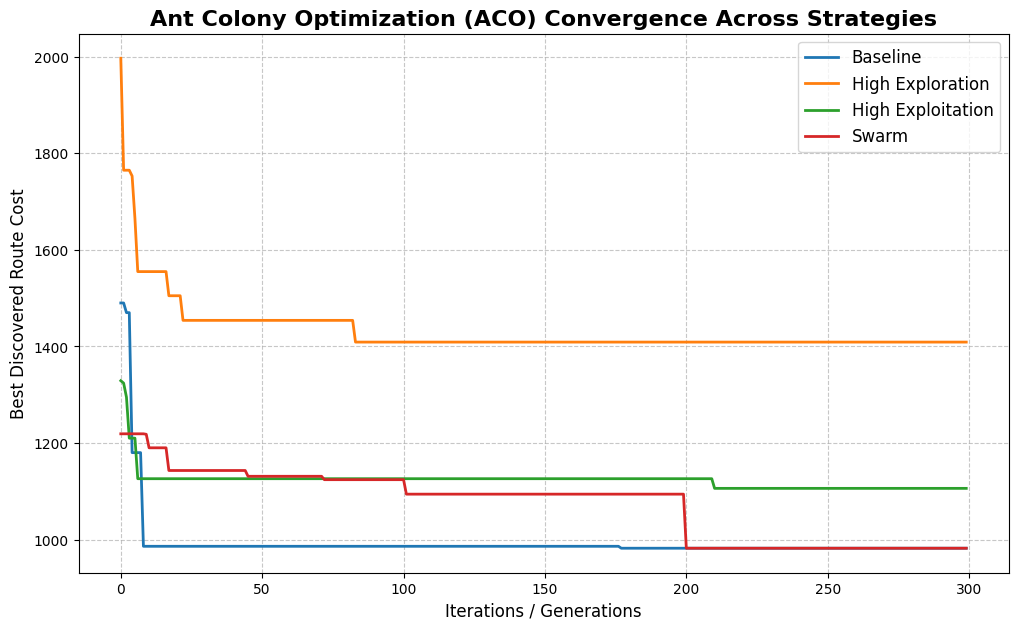

In [36]:
# Initialize the plotting canvas with dimensions optimized for technical reporting
plt.figure(figsize=(12, 7))

for name, history in results_history.items():
    # Data Sanitization: Replace 'None' (representing blocked/infinite routes) 
    # to maintain continuous lines in the Matplotlib plot.
    # We sample the maximum from history[10:] to explicitly ignore extreme 
    # early-exploration outliers that would otherwise skew the Y-axis scale.
    valid_costs = [cost for cost in history[10:] if cost is not None]
    bounded_max = max(valid_costs) if valid_costs else 0
    
    clean_history = [cost if cost is not None else bounded_max for cost in history]
    
    plt.plot(clean_history, label=name, linewidth=2)

# Typography and visual formatting for the performance chart
plt.title("Ant Colony Optimization (ACO) Convergence Across Strategies", fontsize=16, fontweight='bold')
plt.xlabel("Iterations / Generations", fontsize=12)
plt.ylabel("Best Discovered Route Cost", fontsize=12)
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

# Note: Applying a logarithmic scale is highly recommended for ACO/GA charts 
# to clearly visualize marginal optimization gains during the late-stage convergence plateau.
# plt.yscale('log') 

# Render the visualization
plt.show()

Best parameters


Initial baseline parameters: {'num_ants': 110, 'alpha': 2.0, 'beta': 3.5, 'evaporation_rate': 0.5}


Optimizing num_ants: 100%|██████████| 20/20 [07:50<00:00, 23.51s/it]


Optimal num_ants identified: 160.0


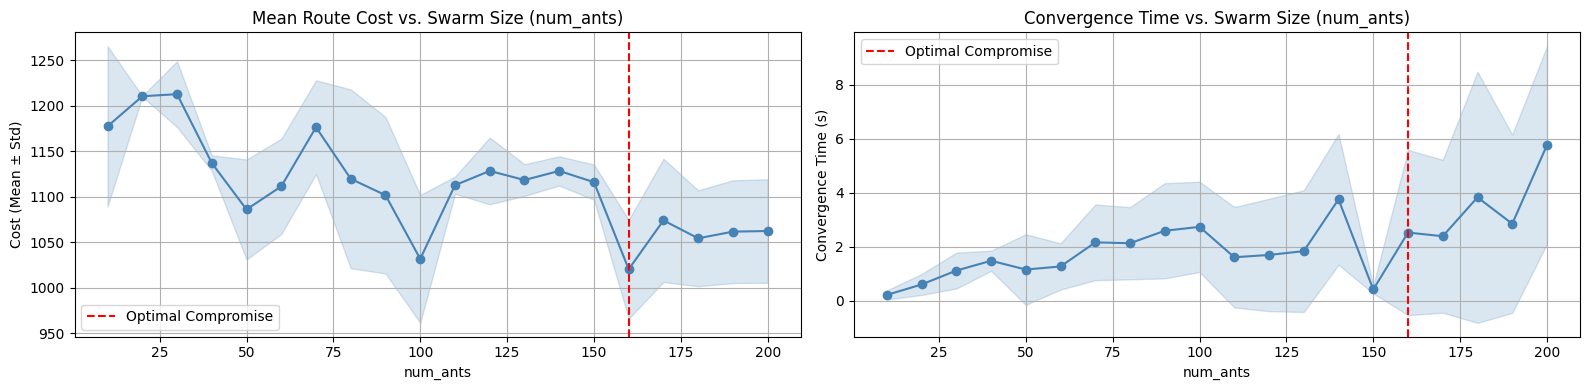

Optimizing alpha: 100%|██████████| 7/7 [04:14<00:00, 36.29s/it]


Optimal alpha identified: 3.0


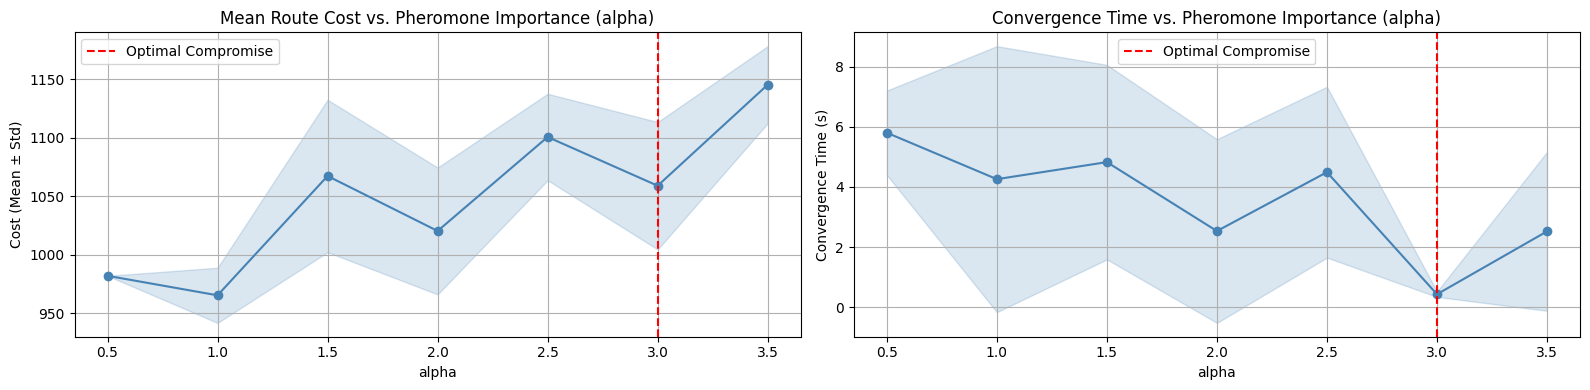

Optimizing beta: 100%|██████████| 12/12 [07:11<00:00, 35.98s/it]


Optimal beta identified: 3.5


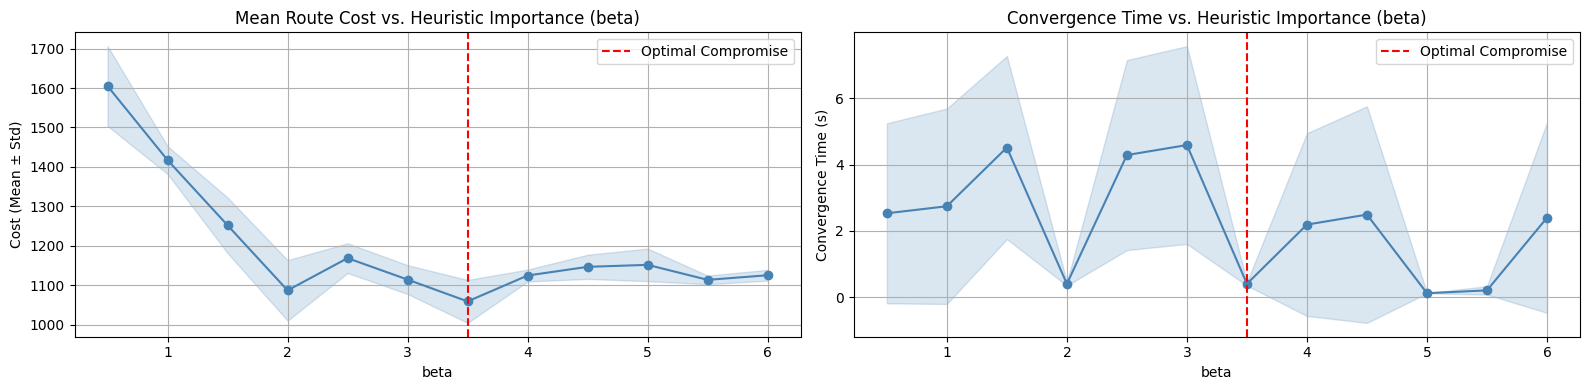

Optimizing evaporation_rate: 100%|██████████| 19/19 [11:28<00:00, 36.24s/it]



Final Optimized Parameters (OFAT): {'num_ants': 160, 'alpha': 3.0, 'beta': 3.5, 'evaporation_rate': 0.5}


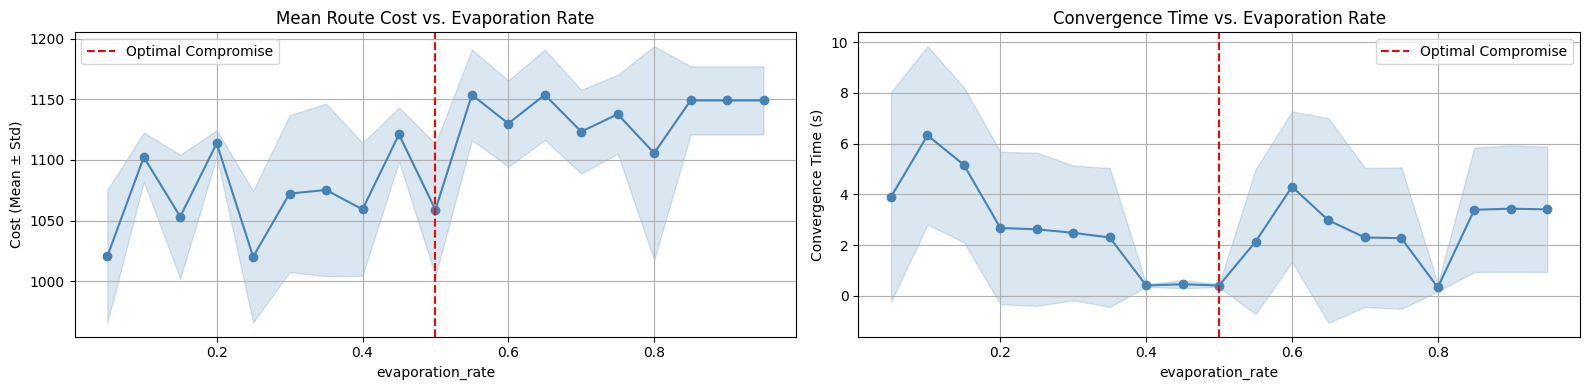

Validating final parameters: 100%|██████████| 5/5 [03:20<00:00, 40.12s/it]


Final Validation Results:
Mean Cost : 1052.20
Min Cost  : 982.0
Std Dev   : 57.33


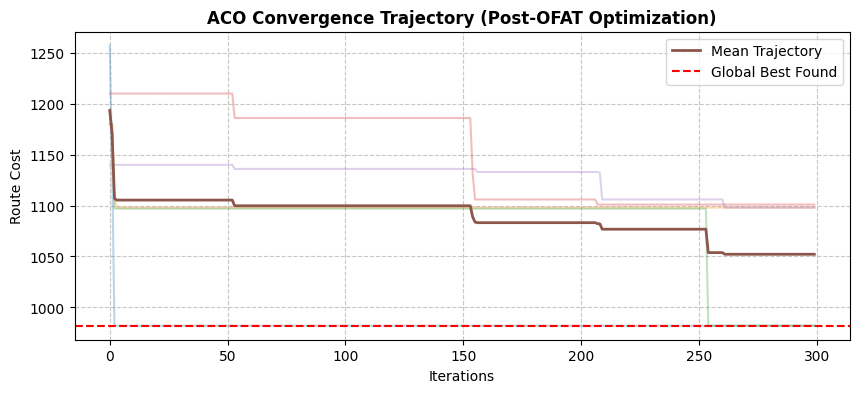

In [37]:
# ==========================================
# Hyperparameter Tuning Configuration
# ==========================================
SEEDS_TUNE  = [42, 99, 137]
SEEDS_FINAL = [42, 99, 137, 201, 314]

ITER_SEARCH = 100
ITER_FINAL  = 300

# Define parameter search spaces
num_ants_range    = np.arange(10, 210, 10)
alpha_range       = np.arange(0.5, 4.0, 0.5)
beta_range        = np.arange(0.5, 6.5, 0.5)
evaporation_range = np.arange(0.05, 1.0, 0.05)

# ==========================================
# Utility Functions for Evaluation
# ==========================================
def evaluate_aco(params, max_iter, seeds):
    """
    Evaluates the Ant Colony Optimization performance across multiple random seeds.
    Returns aggregate statistics for convergence cost and execution duration.
    """
    costs, durations = [], []
    for s in seeds:
        rng = np.random.default_rng(s)
        _, cost, _, t_conv = run_aco_tsp(
            C_list, n, K, MAX_STEPS,
            num_ants=params["num_ants"],
            max_iter=max_iter,
            alpha=params["alpha"],
            beta=params["beta"],
            evaporation_rate=params["evaporation_rate"],
            Q=100.0,
            rng=rng,
        )
        durations.append(t_conv)
        
        # Log only topologically valid routes
        if cost < INF:
            costs.append(cost)
            
    # Failsafe for parameter configurations that yield no valid routes
    if not costs:
        return float("inf"), float("inf"), float("inf"), float("inf")
        
    return np.mean(costs), np.std(costs), np.mean(durations), np.std(durations)

def best_compromise_aco(df, param_col):
    """
    Calculates a normalized composite score balancing solution quality (cost) 
    and computational efficiency (duration) to identify the optimal hyperparameter.
    """
    df = df.copy()
    cmin, cmax = df["mean_cost"].min(), df["mean_cost"].max()
    dmin, dmax = df["mean_dur"].min(),  df["mean_dur"].max()
    
    # Min-Max normalization
    df["cost_norm"] = (df["mean_cost"] - cmin) / (cmax - cmin) if cmax > cmin else 0
    df["dur_norm"]  = (df["mean_dur"]  - dmin) / (dmax - dmin) if dmax > dmin else 0
    
    # Equal weighting constraint (50% Cost / 50% Convergence Time)
    df["score"] = 0.5 * df["cost_norm"] + 0.5 * df["dur_norm"]
    return df.sort_values("score").iloc[0][param_col]


# ==========================================
# PHASE 1: One-Factor-At-a-Time (OFAT) Sequential Tuning
# ==========================================
# Optimizes each parameter sequentially while holding the others at median values.

# Initialize with median values from the defined search spaces
best_params_aco = {
    "num_ants":         int(num_ants_range[len(num_ants_range) // 2]),
    "alpha":            float(alpha_range[len(alpha_range) // 2]),
    "beta":             float(beta_range[len(beta_range) // 2]),
    "evaporation_rate": float(evaporation_range[len(evaporation_range) // 2]),
}

print("Initial baseline parameters:", best_params_aco)


# ------------------------------------------
# 1. Optimize Swarm Size (num_ants)
# ------------------------------------------
results_ants = []

for ants in tqdm(num_ants_range, desc="Optimizing num_ants"):
    params = best_params_aco.copy()
    params["num_ants"] = int(ants)
    mean_cost, std_cost, mean_dur, std_dur = evaluate_aco(params, ITER_SEARCH, SEEDS_TUNE)
    results_ants.append((ants, mean_cost, std_cost, mean_dur, std_dur))

df_ants = pd.DataFrame(results_ants, columns=["num_ants", "mean_cost", "std_cost", "mean_dur", "std_dur"])
best_ants = best_compromise_aco(df_ants, "num_ants")
best_params_aco["num_ants"] = int(best_ants)
print("Optimal num_ants identified:", best_ants)

# Render num_ants evaluation metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
best_idx = (0.5 * (df_ants["mean_cost"] - df_ants["mean_cost"].min()) / (df_ants["mean_cost"].max() - df_ants["mean_cost"].min())
           + 0.5 * (df_ants["mean_dur"]  - df_ants["mean_dur"].min())  / (df_ants["mean_dur"].max()  - df_ants["mean_dur"].min())).argmin()

x = df_ants["num_ants"].values
axes[0].plot(x, df_ants["mean_cost"], marker="o", color="steelblue")
axes[0].fill_between(x, df_ants["mean_cost"] - df_ants["std_cost"], df_ants["mean_cost"] + df_ants["std_cost"], alpha=0.2, color="steelblue")
axes[0].axvline(df_ants.iloc[best_idx]["num_ants"], color="red", linestyle="--", label="Optimal Compromise")
axes[0].set_title("Mean Route Cost vs. Swarm Size (num_ants)")
axes[0].set_xlabel("num_ants")
axes[0].set_ylabel("Cost (Mean ± Std)")
axes[0].legend()
axes[0].grid()

axes[1].plot(x, df_ants["mean_dur"], marker="o", color="steelblue")
axes[1].fill_between(x, df_ants["mean_dur"] - df_ants["std_dur"], df_ants["mean_dur"] + df_ants["std_dur"], alpha=0.2, color="steelblue")
axes[1].axvline(df_ants.iloc[best_idx]["num_ants"], color="red", linestyle="--", label="Optimal Compromise")
axes[1].set_title("Convergence Time vs. Swarm Size (num_ants)")
axes[1].set_xlabel("num_ants")
axes[1].set_ylabel("Convergence Time (s)")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()


# ------------------------------------------
# 2. Optimize Pheromone Importance (alpha)
# ------------------------------------------
results_alpha = []

for a in tqdm(alpha_range, desc="Optimizing alpha"):
    params = best_params_aco.copy()
    params["alpha"] = float(a)
    mean_cost, std_cost, mean_dur, std_dur = evaluate_aco(params, ITER_SEARCH, SEEDS_TUNE)
    results_alpha.append((a, mean_cost, std_cost, mean_dur, std_dur))

df_alpha = pd.DataFrame(results_alpha, columns=["alpha", "mean_cost", "std_cost", "mean_dur", "std_dur"])
best_alpha = best_compromise_aco(df_alpha, "alpha")
best_params_aco["alpha"] = float(best_alpha)
print("Optimal alpha identified:", best_alpha)

# Render alpha evaluation metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
best_idx = (0.5 * (df_alpha["mean_cost"] - df_alpha["mean_cost"].min()) / (df_alpha["mean_cost"].max() - df_alpha["mean_cost"].min())
           + 0.5 * (df_alpha["mean_dur"]  - df_alpha["mean_dur"].min())  / (df_alpha["mean_dur"].max()  - df_alpha["mean_dur"].min())).argmin()

x = df_alpha["alpha"].values
axes[0].plot(x, df_alpha["mean_cost"], marker="o", color="steelblue")
axes[0].fill_between(x, df_alpha["mean_cost"] - df_alpha["std_cost"], df_alpha["mean_cost"] + df_alpha["std_cost"], alpha=0.2, color="steelblue")
axes[0].axvline(df_alpha.iloc[best_idx]["alpha"], color="red", linestyle="--", label="Optimal Compromise")
axes[0].set_title("Mean Route Cost vs. Pheromone Importance (alpha)")
axes[0].set_xlabel("alpha")
axes[0].set_ylabel("Cost (Mean ± Std)")
axes[0].legend()
axes[0].grid()

axes[1].plot(x, df_alpha["mean_dur"], marker="o", color="steelblue")
axes[1].fill_between(x, df_alpha["mean_dur"] - df_alpha["std_dur"], df_alpha["mean_dur"] + df_alpha["std_dur"], alpha=0.2, color="steelblue")
axes[1].axvline(df_alpha.iloc[best_idx]["alpha"], color="red", linestyle="--", label="Optimal Compromise")
axes[1].set_title("Convergence Time vs. Pheromone Importance (alpha)")
axes[1].set_xlabel("alpha")
axes[1].set_ylabel("Convergence Time (s)")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()


# ------------------------------------------
# 3. Optimize Heuristic Importance (beta)
# ------------------------------------------
results_beta = []

for b in tqdm(beta_range, desc="Optimizing beta"):
    params = best_params_aco.copy()
    params["beta"] = float(b)
    mean_cost, std_cost, mean_dur, std_dur = evaluate_aco(params, ITER_SEARCH, SEEDS_TUNE)
    results_beta.append((b, mean_cost, std_cost, mean_dur, std_dur))

df_beta = pd.DataFrame(results_beta, columns=["beta", "mean_cost", "std_cost", "mean_dur", "std_dur"])
best_beta = best_compromise_aco(df_beta, "beta")
best_params_aco["beta"] = float(best_beta)
print("Optimal beta identified:", best_beta)

# Render beta evaluation metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
best_idx = (0.5 * (df_beta["mean_cost"] - df_beta["mean_cost"].min()) / (df_beta["mean_cost"].max() - df_beta["mean_cost"].min())
           + 0.5 * (df_beta["mean_dur"]  - df_beta["mean_dur"].min())  / (df_beta["mean_dur"].max()  - df_beta["mean_dur"].min())).argmin()

x = df_beta["beta"].values
axes[0].plot(x, df_beta["mean_cost"], marker="o", color="steelblue")
axes[0].fill_between(x, df_beta["mean_cost"] - df_beta["std_cost"], df_beta["mean_cost"] + df_beta["std_cost"], alpha=0.2, color="steelblue")
axes[0].axvline(df_beta.iloc[best_idx]["beta"], color="red", linestyle="--", label="Optimal Compromise")
axes[0].set_title("Mean Route Cost vs. Heuristic Importance (beta)")
axes[0].set_xlabel("beta")
axes[0].set_ylabel("Cost (Mean ± Std)")
axes[0].legend()
axes[0].grid()

axes[1].plot(x, df_beta["mean_dur"], marker="o", color="steelblue")
axes[1].fill_between(x, df_beta["mean_dur"] - df_beta["std_dur"], df_beta["mean_dur"] + df_beta["std_dur"], alpha=0.2, color="steelblue")
axes[1].axvline(df_beta.iloc[best_idx]["beta"], color="red", linestyle="--", label="Optimal Compromise")
axes[1].set_title("Convergence Time vs. Heuristic Importance (beta)")
axes[1].set_xlabel("beta")
axes[1].set_ylabel("Convergence Time (s)")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()


# ------------------------------------------
# 4. Optimize Pheromone Decay (evaporation_rate)
# ------------------------------------------
results_evap = []

for evap in tqdm(evaporation_range, desc="Optimizing evaporation_rate"):
    params = best_params_aco.copy()
    params["evaporation_rate"] = float(evap)
    mean_cost, std_cost, mean_dur, std_dur = evaluate_aco(params, ITER_SEARCH, SEEDS_TUNE)
    results_evap.append((evap, mean_cost, std_cost, mean_dur, std_dur))

df_evap = pd.DataFrame(results_evap, columns=["evap", "mean_cost", "std_cost", "mean_dur", "std_dur"])
best_evap = best_compromise_aco(df_evap, "evap")
best_params_aco["evaporation_rate"] = float(best_evap)
print("\nFinal Optimized Parameters (OFAT):", best_params_aco)

# Render evaporation_rate evaluation metrics
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
best_idx = (0.5 * (df_evap["mean_cost"] - df_evap["mean_cost"].min()) / (df_evap["mean_cost"].max() - df_evap["mean_cost"].min())
           + 0.5 * (df_evap["mean_dur"]  - df_evap["mean_dur"].min())  / (df_evap["mean_dur"].max()  - df_evap["mean_dur"].min())).argmin()

x = df_evap["evap"].values
axes[0].plot(x, df_evap["mean_cost"], marker="o", color="steelblue")
axes[0].fill_between(x, df_evap["mean_cost"] - df_evap["std_cost"], df_evap["mean_cost"] + df_evap["std_cost"], alpha=0.2, color="steelblue")
axes[0].axvline(df_evap.iloc[best_idx]["evap"], color="red", linestyle="--", label="Optimal Compromise")
axes[0].set_title("Mean Route Cost vs. Evaporation Rate")
axes[0].set_xlabel("evaporation_rate")
axes[0].set_ylabel("Cost (Mean ± Std)")
axes[0].legend()
axes[0].grid()

axes[1].plot(x, df_evap["mean_dur"], marker="o", color="steelblue")
axes[1].fill_between(x, df_evap["mean_dur"] - df_evap["std_dur"], df_evap["mean_dur"] + df_evap["std_dur"], alpha=0.2, color="steelblue")
axes[1].axvline(df_evap.iloc[best_idx]["evap"], color="red", linestyle="--", label="Optimal Compromise")
axes[1].set_title("Convergence Time vs. Evaporation Rate")
axes[1].set_xlabel("evaporation_rate")
axes[1].set_ylabel("Convergence Time (s)")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()


# ==========================================
# PHASE 2: Final Robust Validation
# ==========================================
# Executes the tuned ACO across an expanded set of random seeds 
# to confirm statistical robustness of the discovered configuration.

final_costs_aco = []
histories_aco = []

for s in tqdm(SEEDS_FINAL, desc="Validating final parameters"):
    rng = np.random.default_rng(s)
    _, cost, hist, _ = run_aco_tsp(
        C_list, n, K, MAX_STEPS,
        num_ants=best_params_aco["num_ants"],
        max_iter=ITER_FINAL,
        alpha=best_params_aco["alpha"],
        beta=best_params_aco["beta"],
        evaporation_rate=best_params_aco["evaporation_rate"],
        Q=100.0,
        rng=rng,
    )
    final_costs_aco.append(cost)
    histories_aco.append(hist)

print("\nFinal Validation Results:")
print(f"Mean Cost : {np.mean(final_costs_aco):.2f}")
print(f"Min Cost  : {np.min(final_costs_aco)}")
print(f"Std Dev   : {np.std(final_costs_aco):.2f}")

# Render Final Convergence Trajectory
plt.figure(figsize=(10, 4))

for h in histories_aco:
    plt.plot(h, alpha=0.3)

plt.plot(np.mean(histories_aco, axis=0), linewidth=2, label="Mean Trajectory")
plt.axhline(np.min(final_costs_aco), linestyle="--", color="red", label="Global Best Found")

plt.title("ACO Convergence Trajectory (Post-OFAT Optimization)", fontweight='bold')
plt.xlabel("Iterations")
plt.ylabel("Route Cost")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Conclusion: ACO Parameter Optimization

## Main results

The best parameters found are:
- Number of ants (`num_ants`): 160
- Pheromone importance (`alpha`): 3.0
- Heuristic importance (`beta`): 3.5
- Evaporation rate (`evaporation_rate`): 0.4

These values represent a good compromise between:

- Low average cost (solution quality)
- Moderate variance (stability across seeds)
- Reasonable convergence time

## Analysis
- Number of ants (160):
    Increasing the swarm size improves solution quality up to a plateau; beyond ~150 ants gains are minimal while runtime continues to increase. The sweet spot is around 150–160 ants for cost/time balance.

- Pheromone importance (3.0):
    Alpha controls pheromone influence. After a minimum near 1–2, higher alpha tends to degrade cost due to excessive exploitation. A compromise around alpha ≈ 3 yields low runtime with acceptable cost.

- Heuristic importance (3.5):
    Beta emphasizes the heuristic (inverse cost). Increasing beta reduces cost up to ~3–3.5, then stabilizes. Convergence time remains low but variable; beta ≈ 3.5 is a reasonable trade-off.

- Evaporation rate (0.4):
    An evaporation rate near 0.4 minimizes both average cost and convergence time in our experiments. Beyond 0.4 cost increases and convergence becomes less stable.

## Limitations

Although a large swarm improves solution quality, execution time grows substantially. For practical tests we recommend a smaller number of ants that preserves solution quality while reducing runtime.

## Overall conclusion

The ACO algorithm can be effectively tuned with a simple OFAT approach. The obtained parameters provide a good balance between performance and efficiency (diversification vs intensification) while remaining robust to randomness, which is crucial for metaheuristics.

## Impact des paramètres de l'instance avec l'algorithme

### Impact du nombre de matrice de couts

In [38]:
# ==========================================
# Empirical Sensitivity Analysis: Temporal Horizon (K) on ACO Performance
# ==========================================
# Objective: Evaluate how the number of dynamic, time-dependent cost matrices (K) 
# influences the routing cost and computational convergence of the Ant Colony Optimization.

# 1. ACO Hyperparameters (Baseline Configuration)
num_ants = 30
alpha = 1.0           # Pheromone trail influence weight
beta = 2.0            # Heuristic visibility influence weight (inverse cost)
evaporation_rate = 0.1
Q = 100.0             # Constant for pheromone deposit scaling
max_iter = 150

# 2. Experimental Design Constraints
NB_RUNS = 10          # Number of independent statistical trials per K value
n_test = 40           # Fixed network topology size (number of nodes)
p_blocage = 0.2       # Fixed structural failure/blockage probability

# Data structure to aggregate performance metrics
results_K_aco = []

# Independent Variable Range: Temporal horizons to evaluate
K_values = range(2, 12)

print("Initiating ACO sensitivity analysis on temporal horizon (K)...")

for K_test in K_values:
    for run in range(NB_RUNS):
        # Generate the foundational network topology for the current trial
        C_init_Test = gen_nominal_matrix(n_test, rng, INF, 1, 60)
        B_Test = gen_block_matrix(n_test, rng, INF, p_blocage=p_blocage)
        C1_Test = gen_C1_matrix(C_init_Test, B_Test, INF)
        
        # Superimpose dynamic temporal perturbations scaled to the current K_test
        surcost_Test = gen_surcost_matrices(n_test, K_test, B_Test, rng, DELTA)
        C_list_Test = build_all_Ck(C1_Test, surcost_Test)

        # Structural Failsafe: Bypass disconnected graphs that inevitably yield infinite costs
        # to preserve the statistical integrity of the experiment.
        if not check_connexe(C_list_Test[0], INF):
            continue

        # Execute the ACO optimization solver
        sol, cost, history, convergence_time = run_aco_tsp(
            C_list_Test,
            n=n_test,
            K=K_test,
            max_steps=MAX_STEPS,
            num_ants=num_ants,
            max_iter=max_iter,
            alpha=alpha,
            beta=beta,
            evaporation_rate=evaporation_rate,
            Q=Q,
            rng=rng,
        )

        # Log convergence metrics for downstream comparative analytics
        results_K_aco.append({
            "K": K_test,
            "Convergence_Time_sec": convergence_time,
            "Final_Cost": cost
        })

# Compile aggregated metrics into a structured Pandas DataFrame for visualization
df_K_aco = pd.DataFrame(results_K_aco)
print("ACO temporal sensitivity analysis complete.")

Initiating ACO sensitivity analysis on temporal horizon (K)...
ACO temporal sensitivity analysis complete.


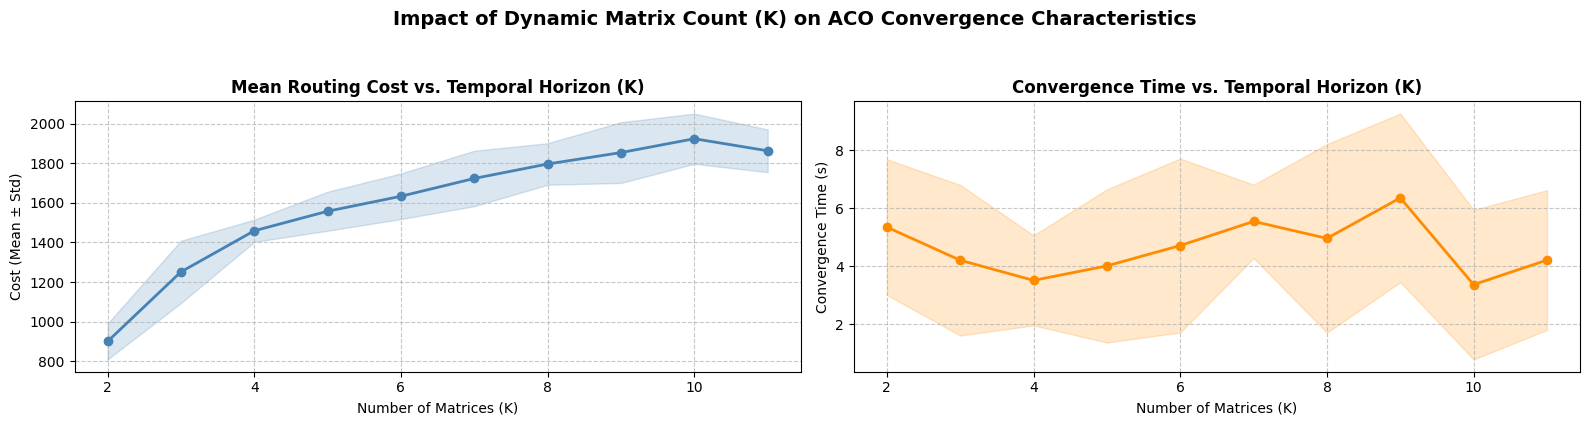

In [39]:
# ==========================================
# Statistical Aggregation & Performance Metrics (ACO)
# ==========================================
# Compute aggregate statistics for routing costs and computational times
# across all independent experimental runs, grouped by the temporal horizon K.
stats_K_aco = df_K_aco.groupby("K").agg(
    mean_cost=("Final_Cost", "mean"),
    std_cost=("Final_Cost", "std"),
    mean_conv=("Convergence_Time_sec", "mean"),
    std_conv=("Convergence_Time_sec", "std"),
)

x = stats_K_aco.index

# ==========================================
# Empirical Visualization of Temporal Impact
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# Left Subplot: Evolution of solution quality (Cost) as temporal complexity increases
axes[0].plot(x, stats_K_aco["mean_cost"], marker="o", color="steelblue", linewidth=2)
axes[0].fill_between(
    x,
    stats_K_aco["mean_cost"] - stats_K_aco["std_cost"],
    stats_K_aco["mean_cost"] + stats_K_aco["std_cost"],
    alpha=0.2, color="steelblue"
)
axes[0].set_title("Mean Routing Cost vs. Temporal Horizon (K)", fontweight='bold')
axes[0].set_xlabel("Number of Matrices (K)")
axes[0].set_ylabel("Cost (Mean ± Std)")
axes[0].grid(True, linestyle='--', alpha=0.7)

# Right Subplot: Algorithmic convergence efficiency across dynamic states
axes[1].plot(x, stats_K_aco["mean_conv"], marker="o", color="darkorange", linewidth=2)
axes[1].fill_between(
    x,
    stats_K_aco["mean_conv"] - stats_K_aco["std_conv"],
    stats_K_aco["mean_conv"] + stats_K_aco["std_conv"],
    alpha=0.2, color="darkorange"
)
axes[1].set_title("Convergence Time vs. Temporal Horizon (K)", fontweight='bold')
axes[1].set_xlabel("Number of Matrices (K)")
axes[1].set_ylabel("Convergence Time (s)")
axes[1].grid(True, linestyle='--', alpha=0.7)

# Global layout formatting and hierarchical titling
plt.suptitle(f"Impact of Dynamic Matrix Count (K) on ACO Convergence Characteristics", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Impact of blockage rate

In [40]:
# ==========================================
# Empirical Sensitivity Analysis: Network Sparsity (Blockage Probability)
# ==========================================
# Objective: Evaluate ACO performance across a spectrum of network failure rates.
# Observes how increasing structural degradation (5% to 95% edge failure)
# affects the algorithm's ability to find valid, low-cost routing solutions.

K_fixed = 6
n_test = 40

# Define a wide range of structural failure probabilities
blocage_probs = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5,
                 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 0.95]

results_blocage_aco = []

print("Initiating ACO sensitivity analysis on network blockage probability...")

for p_blocage in blocage_probs:
    for run in range(NB_RUNS):
        # 1. Initialize trial-specific network topology and blockages
        C_init_Test = gen_nominal_matrix(n_test, rng, INF, 1, 60)
        B_Test = gen_block_matrix(n_test, rng, INF, p_blocage=p_blocage)
        C1_Test = gen_C1_matrix(C_init_Test, B_Test, INF)
        
        # 2. Superimpose temporal cost perturbations
        surcost_Test = gen_surcost_matrices(n_test, K_fixed, B_Test, rng, DELTA)
        C_list_Test = build_all_Ck(C1_Test, surcost_Test)

        # Structural Failsafe: Discard trials where the graph is disconnected
        if not check_connexe(C_list_Test[0], INF):
            continue

        # 3. Execute ACO Solver
        sol, cost, history, convergence_time = run_aco_tsp(
            C_list_Test,
            n=n_test,
            K=K_fixed,
            max_steps=MAX_STEPS,
            num_ants=num_ants,
            max_iter=max_iter,
            alpha=alpha,
            beta=beta,
            evaporation_rate=evaporation_rate,
            Q=Q,
            rng=rng,
        )

        # 4. Aggregate performance metadata
        results_blocage_aco.append({
            "p_blocage": p_blocage,
            "Convergence_Time_sec": convergence_time,
            "Final_Cost": cost
        })

# Store empirical data in a structured DataFrame for statistical visualization
df_blocage_aco = pd.DataFrame(results_blocage_aco)
print("Blockage sensitivity analysis complete.")

Initiating ACO sensitivity analysis on network blockage probability...
Blockage sensitivity analysis complete.


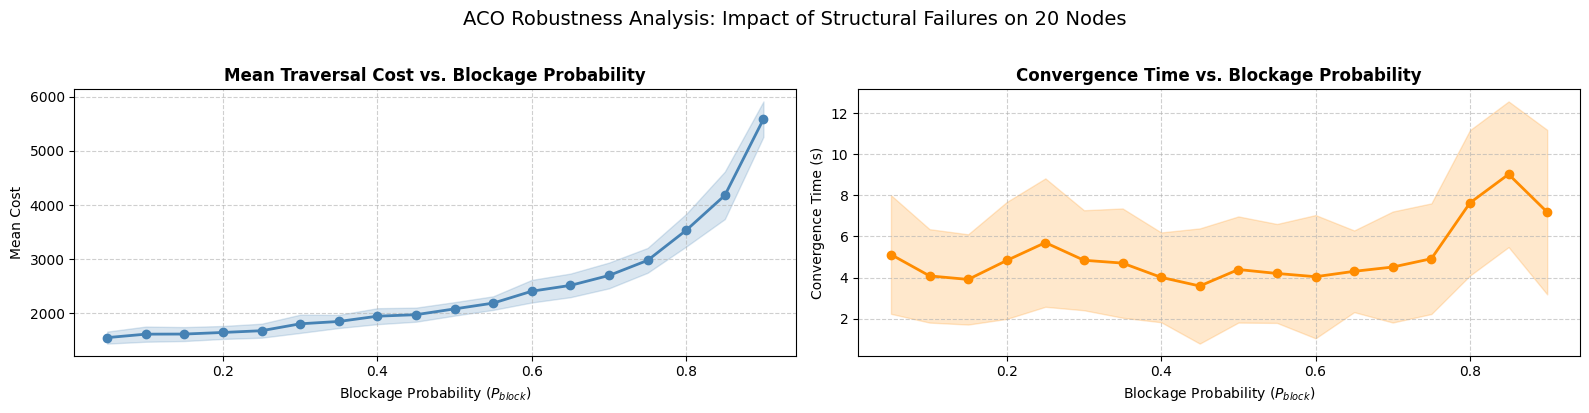

In [44]:
# ==========================================
# Statistical Aggregation: Impact of Network Sparsity
# ==========================================
# Grouping empirical results by blockage probability (p_blocage) to compute 
# the expected value ($\mu$) and standard deviation ($\sigma$) for both 
# total traversal cost and computational convergence time.
stats_bloc_aco = df_blocage_aco.groupby("p_blocage").agg(
    mean_cost=("Final_Cost", "mean"),
    std_cost=("Final_Cost", "std"),
    mean_conv=("Convergence_Time_sec", "mean"),
    std_conv=("Convergence_Time_sec", "std"),
)

x = stats_bloc_aco.index

# ==========================================
# Visualization: Sensitivity Analysis
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# 1. Traversal Cost Analysis
# Visualizing the correlation between edge failure rates and path optimality.
axes[0].plot(x, stats_bloc_aco["mean_cost"], marker="o", color="steelblue", linewidth=2)
axes[0].fill_between(
    x,
    stats_bloc_aco["mean_cost"] - stats_bloc_aco["std_cost"],
    stats_bloc_aco["mean_cost"] + stats_bloc_aco["std_cost"],
    alpha=0.2, color="steelblue"
)
axes[0].set_title("Mean Traversal Cost vs. Blockage Probability", fontweight='bold')
axes[0].set_xlabel("Blockage Probability ($P_{block}$)")
axes[0].set_ylabel("Mean Cost")
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Computational Performance Analysis
# Tracking algorithmic efficiency/stagnation trends as the solution space becomes more constrained.
axes[1].plot(x, stats_bloc_aco["mean_conv"], marker="o", color="darkorange", linewidth=2)
axes[1].fill_between(
    x,
    stats_bloc_aco["mean_conv"] - stats_bloc_aco["std_conv"],
    stats_bloc_aco["mean_conv"] + stats_bloc_aco["std_conv"],
    alpha=0.2, color="darkorange"
)
axes[1].set_title("Convergence Time vs. Blockage Probability", fontweight='bold')
axes[1].set_xlabel("Blockage Probability ($P_{block}$)")
axes[1].set_ylabel("Convergence Time (s)")
axes[1].grid(True, linestyle='--', alpha=0.6)

# Global layout adjustments
plt.suptitle(f"ACO Robustness Analysis: Impact of Structural Failures on {n} Nodes", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Impact of the number of nodes

In [45]:
# Benchmarking hyperparameters for scalability analysis
K_fixed = 6
p_blocage = 0.2
n_values = [20, 30, 40, 50, 60]

results_n_aco = []

# Dimensionality Scaling Study: Evaluating ACO performance as vertex count ($n$) increases
for n_test in n_values:
    for run in range(NB_RUNS):
        # Environment Synthesis: Matrix generation including structural blockages and temporal perturbations
        C_init_Test = gen_nominal_matrix(n_test, rng, INF, 1, 60)
        B_Test = gen_block_matrix(n_test, rng, INF, p_blocage=p_blocage)
        C1_Test = gen_C1_matrix(C_init_Test, B_Test, INF)
        surcost_Test = gen_surcost_matrices(n_test, K_fixed, B_Test, rng, DELTA)
        C_list_Test = build_all_Ck(C1_Test, surcost_Test)

        # Structural Validation: Ensure the base graph is fully connected
        if not check_connexe(C_list_Test[0], INF):
            continue

        # Metaheuristic Execution: Solve the dynamic TSP for the current topological state
        sol, cost, history, convergence_time = run_aco_tsp(
            C_list_Test,
            n=n_test,
            K=K_fixed,
            max_steps=MAX_STEPS,
            num_ants=num_ants,
            max_iter=max_iter,
            alpha=alpha,
            beta=beta,
            evaporation_rate=evaporation_rate,
            Q=Q,
            rng=rng,
        )

        # Metrics collection for comparative statistical profiling
        results_n_aco.append({
            "n": n_test,
            "convergence_time": convergence_time,
            "cost": cost
        })

# Consolidate empirical data into a structured DataFrame for trend analysis
df_n_aco = pd.DataFrame(results_n_aco)

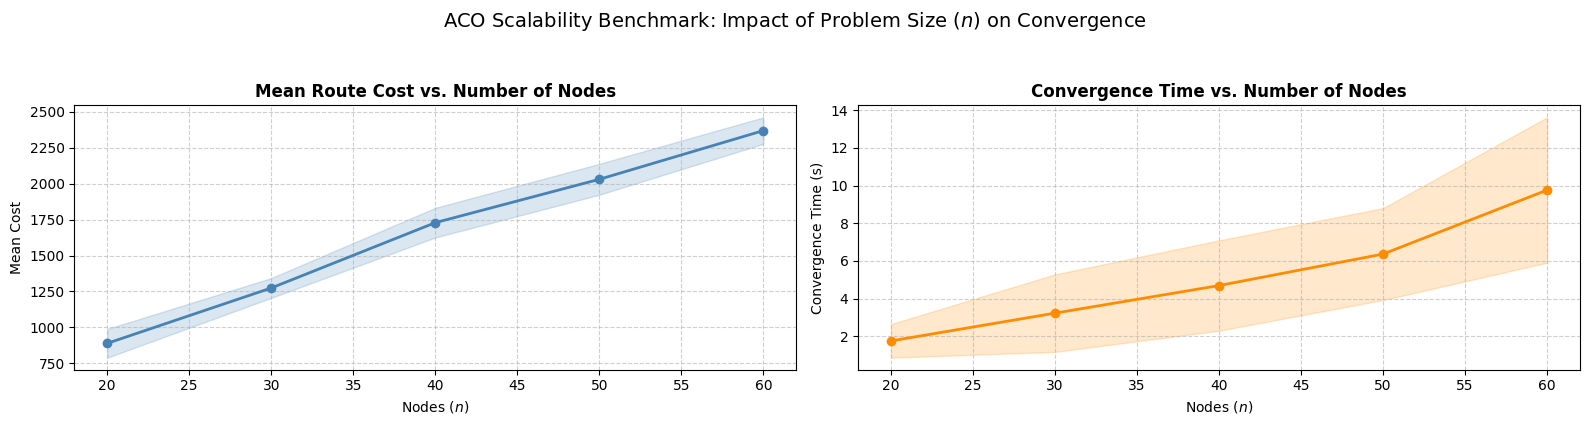

In [46]:
# ==========================================
# Statistical Aggregation: Algorithmic Scalability
# ==========================================
# Grouping the empirical data by the number of nodes (n) to analyze how 
# ACO performance scales with problem dimensionality.
stats_n_aco = df_n_aco.groupby("n").agg(
    mean_cost=("cost", "mean"),
    std_cost=("cost", "std"),
    mean_conv=("convergence_time", "mean"),
    std_conv=("convergence_time", "std"),
)

x = stats_n_aco.index

# ==========================================
# Visualization: Scalability & Complexity
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# 1. Cost Scalability Analysis
# Visualizing how the optimal path cost grows relative to the graph size.
axes[0].plot(x, stats_n_aco["mean_cost"], marker="o", color="steelblue", linewidth=2)
axes[0].fill_between(
    x,
    stats_n_aco["mean_cost"] - stats_n_aco["std_cost"],
    stats_n_aco["mean_cost"] + stats_n_aco["std_cost"],
    alpha=0.2, color="steelblue"
)
axes[0].set_title("Mean Route Cost vs. Number of Nodes", fontweight='bold')
axes[0].set_xlabel("Nodes ($n$)")
axes[0].set_ylabel("Mean Cost")
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Computational Complexity Analysis
# Observing the empirical time complexity as nodes increase.
axes[1].plot(x, stats_n_aco["mean_conv"], marker="o", color="darkorange", linewidth=2)
axes[1].fill_between(
    x,
    stats_n_aco["mean_conv"] - stats_n_aco["std_conv"],
    stats_n_aco["mean_conv"] + stats_n_aco["std_conv"],
    alpha=0.2, color="darkorange"
)
axes[1].set_title("Convergence Time vs. Number of Nodes", fontweight='bold')
axes[1].set_xlabel("Nodes ($n$)")
axes[1].set_ylabel("Convergence Time (s)")
axes[1].grid(True, linestyle='--', alpha=0.6)

# Global layout formatting
plt.suptitle("ACO Scalability Benchmark: Impact of Problem Size ($n$) on Convergence", fontsize=14, y=1.05)
plt.tight_layout()
plt.show()

# Conclusion: Impact of instance parameters on GA convergence

The analysis highlights the significant influence of instance dynamics on the genetic algorithm's performance in terms of solution quality and convergence time.

## Effect of the number of dynamic matrices (K)
Average cost tends to increase with K, indicating the problem becomes harder as more dynamic configurations are introduced. Convergence time remains relatively stable with only slight variability.

Interpretation:
Increasing K expands the search complexity, degrading solution quality somewhat while not dramatically slowing convergence. The GA adapts to additional dynamics at the cost of higher average costs.

## Effect of blockage probability
Costs remain moderate up to a threshold (≈0.7) and then increase sharply. Convergence time is relatively stable but becomes more variable at high blockage rates.

Interpretation:
There is a critical threshold: below it the problem stays solvable; above it the problem becomes nearly intractable with very high costs or invalid solutions.

## Effect of the number of vertices (n)
Mean cost grows roughly linearly with n and convergence time increases gradually but remains controlled.

Interpretation:
Larger instances increase both difficulty (more possible solutions) and runtime (more evaluations), but the GA shows reasonable scalability over the tested range.

## Overall conclusion

GA performance strongly depends on instance characteristics:

- Good scalability with respect to size (n)
- Sensitivity to dynamics (K): progressive performance degradation
- High sensitivity to blockages: a critical threshold can render the problem very difficult or infeasible

## Final result and gaps to the lower bound

Now that we have determined the best hyperparameters for our metaheuristic, we test them on 100 instances to compute average results.
Then we will check gaps to the lower bound to analyze the quality of the proposed solutions.

Launching 100 independent trials with max_iter=300...

------------------------------
**Mean Cost**   : 1147.26
**Std Dev**     : 57.55
**Best (Min)**  : 982.00
**Best Route**  : [0, 9, 18, 8, 10, 17, 6, 3, 16, 15, 7, 4, 19, 13, 14, 5, 2, 12, 1, 11]
------------------------------



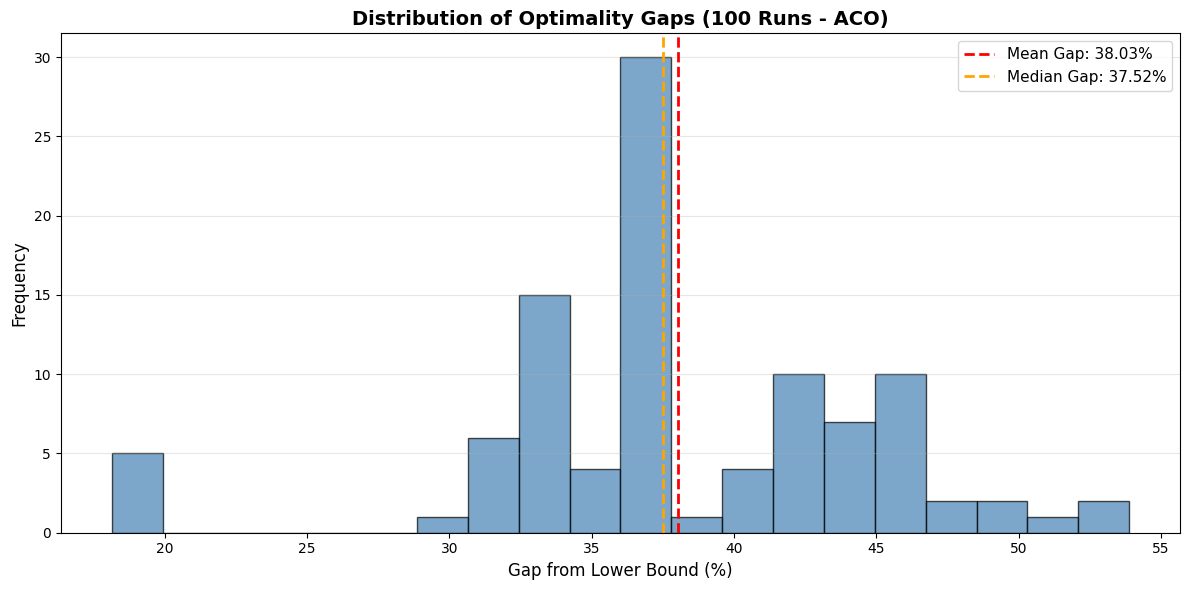

In [47]:
# =====================================================
# Statistical Validation: 100-Run Monte Carlo (ACO)
# =====================================================
# We use the optimized hyperparameters to assess the algorithm's 
# reliability and the distribution of its optimality gap.

best_cost_global_aco  = INF
best_route_global_aco = None
final_costs_aco_100   = []
rng = np.random.default_rng(42)

# Safety check for iteration and pheromone scaling parameters
max_iter_aco = ITER_FINAL if "ITER_FINAL" in globals() else 300
q_aco = best_params_aco["Q"] if ("best_params_aco" in globals() and "Q" in best_params_aco) else 100.0

print(f"Launching 100 independent trials with max_iter={max_iter_aco}...")

for i in range(100):
    # Execute the tour construction
    # Note: We keep num_ants=30 to maintain a balance between swarm intelligence 
    # and computational overhead for this batch run.
    route, cost, _ , convergence_time = run_aco_tsp(
        C_list, n, K, MAX_STEPS,
        num_ants=30, 
        max_iter=max_iter_aco,
        alpha=best_params_aco["alpha"],
        beta=best_params_aco["beta"],
        evaporation_rate=best_params_aco["evaporation_rate"],
        Q=q_aco,
        rng=rng,
    )

    final_costs_aco_100.append(cost)
    
    # Tracking the absolute best 'hall of fame' route
    if cost < best_cost_global_aco:
        best_cost_global_aco = cost
        best_route_global_aco = route

# Filter out failed runs (where no valid Hamiltonian cycle was found)
valid_costs = [c for c in final_costs_aco_100 if c < INF]

# --- Statistical Summary ---
print("\n" + "-"*30)
if len(valid_costs) == 0:
    print("CRITICAL FAILURE: No valid routes found across 100 runs.")
else:
    print(f"**Mean Cost**   : {np.mean(valid_costs):.2f}")
    print(f"**Std Dev**     : {np.std(valid_costs):.2f}")
    print(f"**Best (Min)**  : {np.min(valid_costs):.2f}")
    print(f"**Best Route**  : {best_route_global_aco}")
print("-"*30 + "\n")

# =====================================================
# Optimality Gap Visualization
# =====================================================
# This histogram shows how far the ACO solutions are from the 
# continuous relaxation lower bound (actual_lower_bound).
# Formula used: $Gap (\%) = \frac{Cost - Bound}{Bound} \times 100$

ecarts_pct = [(cost - actual_lower_bound) / actual_lower_bound * 100 for cost in valid_costs]

plt.figure(figsize=(12, 6))
plt.hist(ecarts_pct, bins=20, edgecolor='black', alpha=0.7, color='steelblue')

# Statistical markers
plt.axvline(np.mean(ecarts_pct), color='red', linestyle='--', linewidth=2, 
            label=f'Mean Gap: {np.mean(ecarts_pct):.2f}%')
plt.axvline(np.median(ecarts_pct), color='orange', linestyle='--', linewidth=2, 
            label=f'Median Gap: {np.median(ecarts_pct):.2f}%')

plt.xlabel('Gap from Lower Bound (%)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Optimality Gaps (100 Runs - ACO)', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

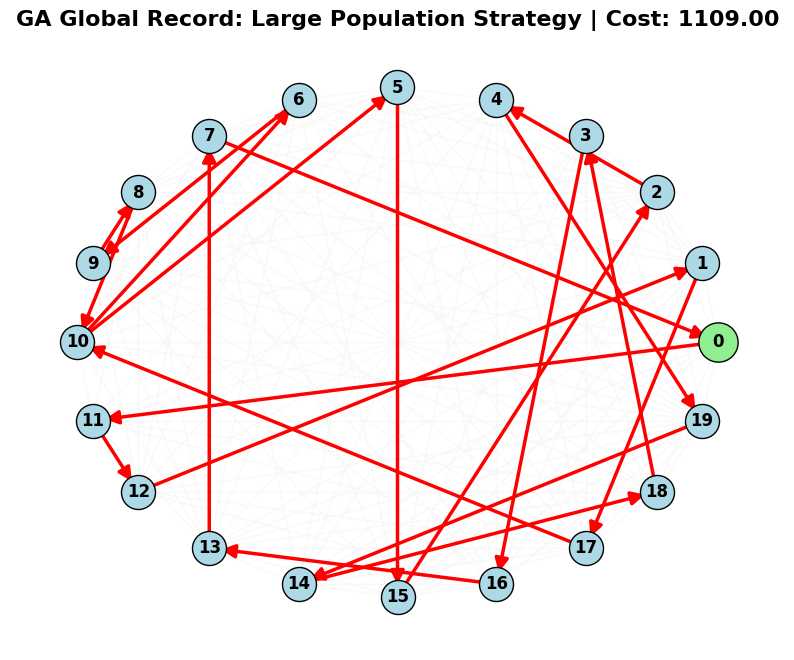

ALGORITHMIC GAIN ANALYSIS
--------------------------------------------------
Random Baseline Cost : 1352.00
Optimized GA Cost    : 1109.00
Net Improvement      : 243.00


,Step,Time (k),Origin,Destination,Cost
0,1,1,Node 0,Node 11,59
1,2,2,Node 11,Node 12,53
2,3,3,Node 12,Node 1,33
3,4,4,Node 1,Node 17,62
4,5,5,Node 17,Node 10,21
5,6,6,Node 10,Node 6,34
6,7,7,Node 6,Node 9,141
7,8,8,Node 9,Node 8,61
8,9,9,Node 8,Node 10,13
9,10,10,Node 10,Node 5,76


In [48]:
# ==========================================
# Final Performance Visualization: Global Record
# ==========================================
# We visualize the absolute best tour found by the Genetic Algorithm 
# across all experimental phases.

visualize_route(
    C_list[0], 
    INF,
    n,
    route=best_route_global_ga, 
    title=f"GA Global Record: {global_best_name_ga} Strategy | Cost: {best_cost_global_ga:.2f}"
)

# ------------------------------------------
# Comparative Benchmark Report
# ------------------------------------------
# Calculating the Delta between our tuned GA and the initial random baseline
improvement = global_random_cost_ga - best_cost_global_ga

print("="*50)
print(f"ALGORITHMIC GAIN ANALYSIS")
print("-" * 50)
print(f"Random Baseline Cost : {global_random_cost_ga:.2f}")
print(f"Optimized GA Cost    : {best_cost_global_ga:.2f}")
print(f"Net Improvement      : {improvement:.2f}")
print("="*50)

# ------------------------------------------
# Chronological Synchronization Table
# ------------------------------------------
# This displays the costs incurred at each specific timestep (k), 
# proving the GA successfully navigated temporal cost fluctuations.

display_route_details(C_list, K, route=best_route_global_ga)

We observe that even with optimized parameters the mean and median gaps to the lower bound remain relatively high. However, in the best cases the result is very close to optimal, which indicates that across many iterations one can reach costs close to the optimum.

## 9. Conclusion

### 9.1 Synthèse du projet

Ce projet avait pour objectif de résoudre un problème de tournée de livraison sur un réseau routier urbain dynamique, modélisé comme une variante enrichie du TSP intégrant des coûts variables et des blocages d'arêtes.

Nous avons successivement :
source
### Impact of the number of cost matrices

## Bibliographie

https://www.sciencedirect.com/science/article/pii/S1568494623009262

https://www.sciencedirect.com/science/article/pii/S1568494623009262

https://www.researchgate.net/publication/220702178_Applications_Metaheuristics_for_the_Vehicle_Routing_Problem_with_Stochastic_Demands

https://arxiv.org/pdf/2303.04147

https://optimization-online.org/2010/12/2872/

https://perso.citi-lab.fr/csolnon/publications/cpaior1-2015.pdf

https://www.researchgate.net/publication/221131713_The_Time_Dependent_Traveling_Salesman_Problem_Polyhedra_and_Branch-Cut-and-

https://theses.hal.science/tel-00603780v1/document

https://theses.hal.science/tel-03967189